# Data Analysis

### Data Analysis → Customer Segmentation + XAI → Product Recommendation + XAI → Sales Prediction per Product + XAI → Daily Sales Prediction + XAI 

**Superstore sales dataset – (2014 - 2017 - 4 years of transactions)**
- It contains information on products, regions, categories, and customer segments.
- Row Count is 9,994 rows and 21 columns, the size is 2.29 MB
- Limited number of records per day (average 1–2 orders/day) 

| Column Name   | Description |
|--------------|------------|
| Row ID        | Unique ID for each row |
| Order ID      | Unique Order ID for each customer |
| Order Date    | Date when the product was ordered |
| Ship Date     | Date when the product was shipped |
| Ship Mode     | Shipping mode selected by the customer |
| Customer ID   | Unique identifier assigned to each customer |
| Customer Name | Name of the customer |
| Segment       | Market segment (Consumer, Corporate, Home Office) |
| Country       | Country of residence of the customer |
| City          | City of residence of the customer |
| State         | State of residence of the customer |
| Postal Code   | Postal code of the customer’s address |
| Region        | Geographic region of the customer |
| Product ID    | Unique identifier of the product |
| Category      | Main category of the ordered product |
| Sub-Category  | Sub-category of the ordered product |
| Product Name  | Name or title of the product |
| Sales         | Total sales value of the product |
| Quantity      | Number of units of the product sold |
| Discount      | Discount applied to the sale |
| Profit        | Profit or loss incurred from the sale |

**Exploratory Data Analysis**
1. Temporal Analysis (Order Data per Time)
2. Customer Analysis
3. Geographical Analysis
4. Product Analysis
5. Sales and Financial Analysis
6. Shipping mode Analysis
7. Outlier Detection (Sales, Profit, Quantity, Discount, Shipping days)
8. Profitability Analysis
9. Segment wise  Analysis (Consumer, Corporate, Home Office)
10. Region Performance Comparsion (Central, East, South, West)
11. Category × Segment Interaction
12. Time Series Trends

## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D   
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Enhanced visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

## Load Dataset

In [2]:
data = pd.read_csv('Sample_Superstore.csv', encoding='latin-1')
data

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [3]:
# Convert dates to datatime type Data (Order Date, Ship Date)
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [4]:
# Data information
print(f"\n📊 Dataset Shape: {data.shape}")
print(f"   - Total Rows (Total Orders): {data.shape[0]:,}")
print(f"   - Total Columns: {data.shape[1]}")
print(f"Date Range: {data['Order Date'].min()} to {data['Order Date'].max()}")


📊 Dataset Shape: (9994, 21)
   - Total Rows (Total Orders): 9,994
   - Total Columns: 21
Date Range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [5]:
# Unique value analysis
print(f"\n🔍 Uniqueness Analysis:")
print(f"   • Number of Customers: {data['Customer ID'].nunique():,}")
print(f"   • Number of Orders: {data['Order ID'].nunique():,}")
print(f"   • Number of Categories: {data['Category'].nunique()}")
print(f"   • Number of Sub-Categories: {data['Sub-Category'].nunique()}")
print(f"   • Number of Products: {data['Product Name'].nunique():,}")
print(f"   • Number of Cities: {data['City'].nunique()}")
print(f"   • Number of States: {data['State'].nunique()}")
print(f"   • Number of Regions: {data['Region'].nunique()}")


🔍 Uniqueness Analysis:
   • Number of Customers: 793
   • Number of Orders: 5,009
   • Number of Categories: 3
   • Number of Sub-Categories: 17
   • Number of Products: 1,850
   • Number of Cities: 531
   • Number of States: 49
   • Number of Regions: 4


In [6]:
# Drop to original product name column and rename sub-category column to new column named -> product name 
data = data.drop(columns=['Product Name']).rename(columns={'Sub-Category': 'Product Name'})

In [7]:
print(f"\n📊 Dataset Shape: {data.shape}")
print(f"   - Total Rows (Total Orders): {data.shape[0]:,}")
print(f"   - Total Columns: {data.shape[1]}")
print(f"Number of Unique Category: {data['Category'].nunique()}")
print(f"Number of Unique Product Name: {data['Product Name'].nunique()}")


📊 Dataset Shape: (9994, 20)
   - Total Rows (Total Orders): 9,994
   - Total Columns: 20
Number of Unique Category: 3
Number of Unique Product Name: 17


## Data Preprocessing

- Check missing values
- Check duplicates 
- Drop NaN value

In [8]:
# Check for missing values
print(f"\nMissing Values:\n{data.isnull().sum()}")


Missing Values:
ï»¿Row ID        0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
# Remove duplicates
data = data.drop_duplicates().reset_index(drop=True)

In [10]:
# Drop missing critical values (NaN values)
data = data.dropna(subset=['Order Date', 'Customer ID', 'Sales'])

In [11]:
print(f"\n📊 Basic Dataset Information:")
data.info()


📊 Basic Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ï»¿Row ID      9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object     

## Feature Engnieering

#### (1)Temporal Features

In [12]:
# Extract new features = 13 features
data['Year'] = data['Order Date'].dt.year    # Year of order was placed
data['Month'] = data['Order Date'].dt.month   # month of the order, useful for identifying seasonal patterns
data['Quarter'] = data['Order Date'].dt.quarter   # Divides the year into four periods to analyze sales behavior
data['Day_of_Week'] = data['Order Date'].dt.dayofweek  # (0 = Monday, 6 = Sunday)
data['Day_Name'] = data['Order Date'].dt.day_name()  # actual weekday name for interpretability
data['Month_Name'] = data['Order Date'].dt.month_name()  # the name of the month
data['Week_of_Year'] = data['Order Date'].dt.isocalendar().week  # the week number of the year
data['Is_Weekend'] = data['Day_of_Week'].isin([5, 6]).astype(int) # Binary feature of order was placed on a weekend
data['Is_Month_Start'] = data['Order Date'].dt.is_month_start.astype(int) # the order was placed at the beginning of the month
data['Is_Month_End'] = data['Order Date'].dt.is_month_end.astype(int)  # the order was placed at the end of the month
data['Days_Since_Start'] = (data['Order Date'] - data['Order Date'].min()).dt.days  # the number of days since the first order

# Shipping days
data['Shipping_Days'] = (data['Ship Date'] - data['Order Date']).dt.days

#### (2) Financial Features

In [13]:
data['Profit_Margin'] = (data['Profit'] / data['Sales']) * 100  # percentage of profit relative to sales
data['Revenue_Per_Unit'] = data['Sales'] / data['Quantity']  # the average revenue generated per unit sold
data['Profit_Per_Unit'] = data['Profit'] / data['Quantity']  # the average profit earned from each unit
data['Discount_Amount'] = data['Sales'] * data['Discount']  # Calculates the monetary value of the applied discount
data['Is_Profitable'] = (data['Profit'] > 0).astype(int) # Binary feature for resulted in profit
data['Is_Loss'] = (data['Profit'] < 0).astype(int)  # Binary feature for resulted in loss.

# Categorizes Profit of transactions into (Loss, Low Profit, Medium Profit, and High Profit)
data['Profit_Category'] = pd.cut(data['Profit'], bins=[-np.inf, 0, 50, 100, np.inf],
                                   labels=['Loss', 'Low_Profit', 'Medium_Profit', 'High_Profit'])
# Handle infinity values
data['Profit_Margin'] = data['Profit_Margin'].replace([np.inf, -np.inf], 0)
data['Revenue_Per_Unit'] = data['Revenue_Per_Unit'].replace([np.inf, -np.inf], 0)
data['Profit_Per_Unit'] = data['Profit_Per_Unit'].replace([np.inf, -np.inf], 0)

In [14]:
data

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Is_Month_End,Days_Since_Start,Shipping_Days,Profit_Margin,Revenue_Per_Unit,Profit_Per_Unit,Discount_Amount,Is_Profitable,Is_Loss,Profit_Category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0,1040,3,16.00,130.9800,20.9568,0.000000,1,0,Low_Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0,1040,3,30.00,243.9800,73.1940,0.000000,1,0,High_Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0,891,4,47.00,7.3100,3.4357,0.000000,1,0,Low_Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0,646,7,-40.00,191.5155,-76.6062,430.909875,0,1,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0,646,7,11.25,11.1840,1.2582,4.473600,1,0,Low_Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,0,18,2,16.25,8.4160,1.3676,5.049600,1,0,Low_Profit
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0,1150,5,17.00,45.9800,7.8166,0.000000,1,0,Low_Profit
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0,1150,5,7.50,129.2880,9.6966,51.715200,1,0,Low_Profit
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0,1150,5,45.00,7.4000,3.3300,0.000000,1,0,Low_Profit


#### (4) Customer-level Aggregations (Analysis for customer segmentation)

In [15]:
customer_stats = data.groupby('Customer ID').agg({
    'Order ID': 'count',
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order Date': ['min', 'max']}).reset_index()
customer_stats.columns = ['Customer ID', 'Total_Orders', 'Total_Sales', 'Avg_Sales','Total_Profit', 
                          'Avg_Profit', 'Total_Quantity','First_Order_Date', 'Last_Order_Date']
customer_stats

,Customer ID,Total_Orders,Total_Sales,Avg_Sales,Total_Profit,Avg_Profit,Total_Quantity,First_Order_Date,Last_Order_Date
0,AA-10315,11,5563.560,505.778182,-362.8825,-32.989318,30,2014-03-31,2017-06-29
1,AA-10375,15,1056.390,70.426000,277.3824,18.492160,41,2014-04-21,2017-12-11
2,AA-10480,12,1790.512,149.209333,435.8274,36.318950,36,2014-05-04,2017-04-15
3,AA-10645,18,5086.935,282.607500,857.8033,47.655739,64,2014-06-22,2017-11-05
4,AB-10015,6,886.156,147.692667,129.3465,21.557750,13,2014-02-18,2016-11-10
...,...,...,...,...,...,...,...,...,...
788,XP-21865,28,2374.658,84.809214,621.2300,22.186786,100,2014-01-20,2017-11-17
789,YC-21895,8,5454.350,681.793750,1305.6290,163.203625,31,2014-11-17,2017-12-26
790,YS-21880,12,6720.444,560.037000,1778.2923,148.191025,58,2015-01-12,2017-12-21
791,ZC-21910,31,8025.707,258.893774,-1032.1490,-33.295129,105,2014-10-13,2017-11-06


#### (5) Product-level Aggregations (Analysis for product recommendation)

In [16]:
product_stats = data.groupby('Product Name').agg({
    'Order ID': 'count',
    'Sales': 'mean',
    'Profit': 'mean',}).reset_index()
product_stats.columns = ['Product Name', 'total_orders', 'Avg_Sales','Avg_Profit']
product_stats

,Product Name,total_orders,Avg_Sales,Avg_Profit
0,Accessories,775,215.974604,54.111788
1,Appliances,466,230.755710,38.922758
2,Art,796,34.068834,8.200737
3,Binders,1523,133.560560,19.843574
4,Bookcases,228,503.859633,-15.230509
5,Chairs,617,532.332420,43.095894
6,Copiers,68,2198.941618,817.909190
7,Envelopes,254,64.867724,27.418019
8,Fasteners,217,13.936774,4.375660
9,Furnishings,957,95.825668,13.645918


#### Remove Unwanted Features

In [17]:
data = data.drop(columns=['ï»¿Row ID', 'Country', 'Postal Code'])

In [18]:
print(f"\n📊 Dataset Shape: {data.shape}")
print(f"   - Total Rows (Total Orders): {data.shape[0]:,}")
print(f"   - Total Columns: {data.shape[1]}")
print(f"Number of Unique Customers: {data['Customer ID'].nunique()}")
print(f"Number of Unique Category: {data['Category'].nunique()}")
print(f"Number of Unique Product Name: {data['Product Name'].nunique()}")    
print(f"Date Range: {data['Order Date'].min()} to {data['Order Date'].max()}")
data


📊 Dataset Shape: (9994, 36)
   - Total Rows (Total Orders): 9,994
   - Total Columns: 36
Number of Unique Customers: 793
Number of Unique Category: 3
Number of Unique Product Name: 17
Date Range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Region,...,Is_Month_End,Days_Since_Start,Shipping_Days,Profit_Margin,Revenue_Per_Unit,Profit_Per_Unit,Discount_Amount,Is_Profitable,Is_Loss,Profit_Category
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,...,0,1040,3,16.00,130.9800,20.9568,0.000000,1,0,Low_Profit
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,...,0,1040,3,30.00,243.9800,73.1940,0.000000,1,0,High_Profit
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,West,...,0,891,4,47.00,7.3100,3.4357,0.000000,1,0,Low_Profit
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,...,0,646,7,-40.00,191.5155,-76.6062,430.909875,0,1,Loss
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,...,0,646,7,11.25,11.1840,1.2582,4.473600,1,0,Low_Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,Miami,Florida,South,...,0,18,2,16.25,8.4160,1.3676,5.049600,1,0,Low_Profit
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,West,...,0,1150,5,17.00,45.9800,7.8166,0.000000,1,0,Low_Profit
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,West,...,0,1150,5,7.50,129.2880,9.6966,51.715200,1,0,Low_Profit
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,West,...,0,1150,5,45.00,7.4000,3.3300,0.000000,1,0,Low_Profit


## Exploratory Data Analysis

### (1)  Temporal Analysis (Count Order over Time)

In [19]:
print(f"\n📅 Time Period Cover:")
print(f"   • Analysis Period: {data['Order Date'].min().date()} to {data['Order Date'].max().date()}")
print(f"   • Total Duration: {(data['Order Date'].max() - data['Order Date'].min()).days} days (~{(data['Order Date'].max() - data['Order Date'].min()).days/365:.1f} years)")
print(f"   • Data Rows: {len(data):,} transactions")
print(f"   • Average Daily Orders: {len(data) / (data['Order Date'].max() - data['Order Date'].min()).days:.2f}")


📅 Time Period Cover:
   • Analysis Period: 2014-01-03 to 2017-12-30
   • Total Duration: 1457 days (~4.0 years)
   • Data Rows: 9,994 transactions
   • Average Daily Orders: 6.86


In [20]:
# Yearly Performance and Growth Analysis
print(f"\n📊 Yearly Trends:")
yearly_stats = data.groupby('Year').agg({
    'Order ID': 'count',
    'Sales': 'sum',
    'Profit': 'sum',
    'Customer ID': 'nunique',
    'Discount': 'mean'}).round(2)
yearly_stats.columns = ['Orders', 'Total_Sales', 'Total_Profit', 'Customers', 'Avg_Discount']
print(yearly_stats)

# Calculate year-over-year growth
yearly_growth = yearly_stats.pct_change() * 100
print(f"\n📈 Year Over Year Growth Rates(%):")
print(yearly_growth.round(2))


📊 Yearly Trends:
      Orders  Total_Sales  Total_Profit  Customers  Avg_Discount
Year                                                            
2014    1993    484247.50      49543.97        595          0.16
2015    2102    470532.51      61618.60        573          0.16
2016    2587    609205.60      81795.17        638          0.15
2017    3312    733215.26      93439.27        693          0.16

📈 Year Over Year Growth Rates(%):
      Orders  Total_Sales  Total_Profit  Customers  Avg_Discount
Year                                                            
2014     NaN          NaN           NaN        NaN           NaN
2015    5.47        -2.83         24.37      -3.70          0.00
2016   23.07        29.47         32.74      11.34         -6.25
2017   28.02        20.36         14.24       8.62          6.67


**Key Insights**

🔹 Orders Growth: growth of 5.47% in 2015 was followed by a strong acceleration in 2016 (23.07%) and 2017 (28.02%).

🔹 Total Sales Growth: decrease in 2015 (−2.83%), althought an increase in orders, and strong growth in 2016 (29.47%), followed by continued growth in 2017 (20.36%).

🔹 Total Profit Growth: The highest increase was observed in 2016 (32.74%), while growth slowed but remained positive in 2017 (14.24%).

🔹 Customer Growth: The number of customers decreased in 2015 (−3.70%), but strongly in 2016 (11.34%) and 2017 (8.62%).

🔹 Average Discount Growth: Average discounts remained relatively stable over the years and decreases in 2016 (−6.25%)with strong sales and profit growth

In [21]:
# Monthly analysis
print(f"\n📊 Monthly Orders:")
monthly_counts = data['Month_Name'].value_counts()
print(monthly_counts.sort_index())


📊 Monthly Orders:
Month_Name
April         668
August        706
December     1408
February      300
January       381
July          710
June          717
March         696
May           735
November     1471
October       819
September    1383
Name: count, dtype: int64


In [22]:
# Day of week analysis
print(f"\n📊 Day of Week Orders:")
dow_counts = data['Day_Name'].value_counts()
print(dow_counts)


📊 Day of Week Orders:
Day_Name
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64


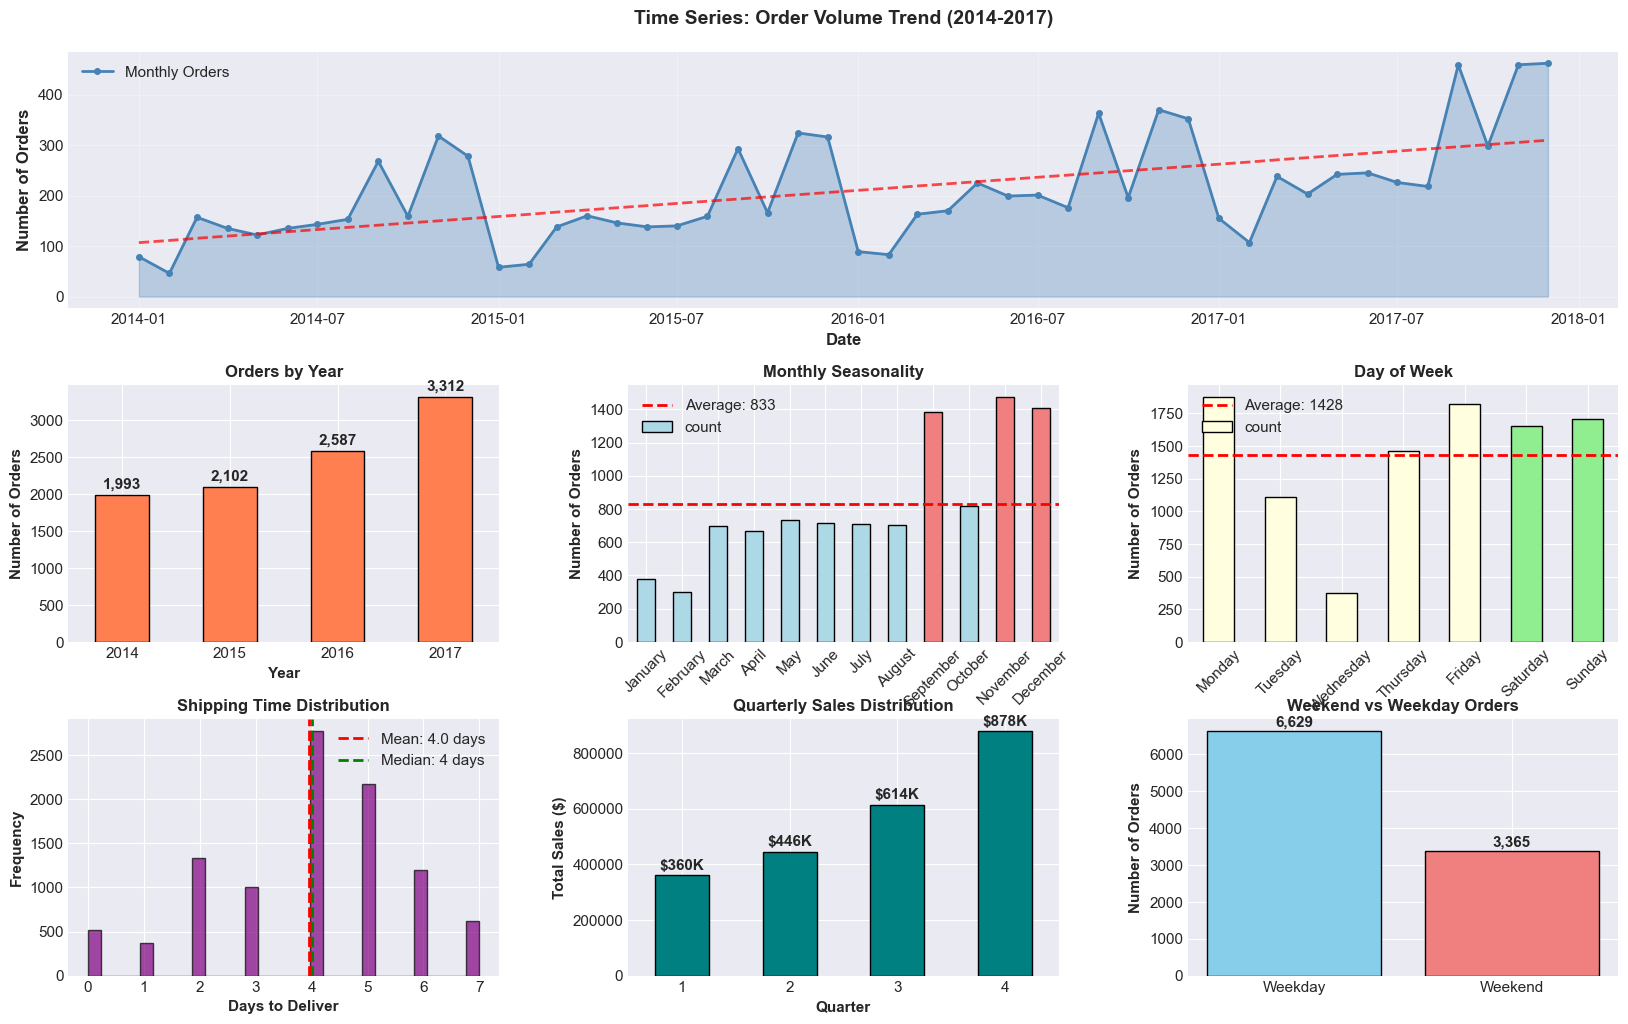

In [23]:
# Visualization: Comprehensive Temporal Analysis
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Time Series: Order Volume Trend (2014-2017)
ax1 = fig.add_subplot(gs[0, :])
monthly_orders = data.groupby(data['Order Date'].dt.to_period('M')).size()
monthly_orders.index = monthly_orders.index.to_timestamp()
ax1.plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, markersize=4, color='steelblue', label='Monthly Orders')
ax1.fill_between(monthly_orders.index, monthly_orders.values, alpha=0.3, color='steelblue')
ax1.set_title('Time Series: Order Volume Trend (2014-2017)', fontsize=14, pad=20)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add trend line
z = np.polyfit(range(len(monthly_orders)), monthly_orders.values, 1)
p = np.poly1d(z)
ax1.plot(monthly_orders.index, p(range(len(monthly_orders))), "--", color='red', linewidth=2, label='Trend Line', alpha=0.7)

# 2. Orders by Year
ax2 = fig.add_subplot(gs[1, 0])
yearly_stats['Orders'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Orders by Year', fontsize=12)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.tick_params(axis='x', rotation=0)
for i, v in enumerate(yearly_stats['Orders']):
    ax2.text(i, v + 50, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# 3. Monthly seasonality
ax3 = fig.add_subplot(gs[1, 1])
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_data_sorted = data['Month_Name'].value_counts().reindex(month_order)
colors_month = ['lightcoral' if x in ['November', 'December', 'September'] 
                else 'lightblue' for x in month_order]
monthly_data_sorted.plot(kind='bar', ax=ax3, color=colors_month, edgecolor='black')
ax3.set_title('Monthly Seasonality', fontsize=12)
ax3.set_xlabel('-', fontsize=11)
ax3.set_ylabel('Number of Orders', fontsize=11)
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=monthly_data_sorted.mean(), color='red', linestyle='--', linewidth=2, label=f'Average: {monthly_data_sorted.mean():.0f}')
ax3.legend()

# 4. Day of week pattern
ax4 = fig.add_subplot(gs[1, 2])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data_sorted = data['Day_Name'].value_counts().reindex(day_order)
colors_dow = ['lightgreen' if x in ['Saturday', 'Sunday'] else 'lightyellow' for x in day_order]
dow_data_sorted.plot(kind='bar', ax=ax4, color=colors_dow, edgecolor='black')
ax4.set_title('Day of Week', fontsize=12)
ax4.set_xlabel('-', fontsize=11)
ax4.set_ylabel('Number of Orders', fontsize=11)
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=dow_data_sorted.mean(), color='red', linestyle='--', linewidth=2, label=f'Average: {dow_data_sorted.mean():.0f}')
ax4.legend()

# 5. Shipping days distribution
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(data['Shipping_Days'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax5.axvline(data['Shipping_Days'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["Shipping_Days"].mean():.1f} days')
ax5.axvline(data['Shipping_Days'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data["Shipping_Days"].median():.0f} days')
ax5.set_title('Shipping Time Distribution', fontsize=12)
ax5.set_xlabel('Days to Deliver', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.legend()

# 6. Sales by quarter
ax6 = fig.add_subplot(gs[2, 1])
quarterly_sales = data.groupby('Quarter')['Sales'].sum()
quarterly_sales.plot(kind='bar', ax=ax6, color='teal', edgecolor='black')
ax6.set_title('Quarterly Sales Distribution', fontsize=12)
ax6.set_xlabel('Quarter', fontsize=11)
ax6.set_ylabel('Total Sales ($)', fontsize=11)
ax6.tick_params(axis='x', rotation=0)
for i, v in enumerate(quarterly_sales):
    ax6.text(i, v + 10000, f'${v/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

# 7. Weekend vs Weekday
ax7 = fig.add_subplot(gs[2, 2])
weekend_comparison = data.groupby('Is_Weekend').agg({'Order ID': 'count','Sales': 'sum'}).reset_index()
weekend_comparison['Type'] = weekend_comparison['Is_Weekend'].map({0: 'Weekday', 1: 'Weekend'})
ax7.bar(weekend_comparison['Type'], weekend_comparison['Order ID'], color=['skyblue', 'lightcoral'], edgecolor='black')
ax7.set_title('Weekend vs Weekday Orders', fontsize=12)
ax7.set_ylabel('Number of Orders', fontsize=11)
for i, v in enumerate(weekend_comparison['Order ID']):
    ax7.text(i, v + 50, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')
    
# plt.tight_layout()
# plt.savefig('temporal_analysis.png', dpi=300, bbox_inches='tight')

**Key insights**

1️⃣ Orders Over time: upward trend at end of each year suggest high-demand periods (e.g., holidays, promotions).

2️⃣ Orders by Year: Orders increase over year

3️⃣ Orders by Month: Orders increase in September–December, February shows the lowest demand.
       
4️⃣ Orders by Day_of_Week: Monday, Friday, Saturday, and Sunday have the highest order volumes, Wednesday has the lowest activity.

5️⃣ Shipping Days Distribution: Most orders are delivered between 3–5 days and few extreme delays (6–7 days. Distribution is slightly right-skewed.
          
6️⃣ Quarter sales Distribution: Orders increase in last quarter in each year 

7️⃣ Weekend vs Weekday: Orders increase in weekday 

**Business Insights**

In [24]:
print(f"\n💡 Key Temporal Insights for Sales Forecasting:")

# Calculate peak months
peak_months = monthly_data_sorted.nlargest(3)
print(f"\n   🔺 Top Sales Months:")
for month, count in peak_months.items():
    print(f"      • {month}: {count} orders ({count/monthly_data_sorted.sum()*100:.1f}% of annual orders)")

# Calculate low months
low_months = monthly_data_sorted.nsmallest(3)
print(f"\n   🔻 Low Sales Months:")
for month, count in low_months.items():
    print(f"      • {month}: {count} orders ({count/monthly_data_sorted.sum()*100:.1f}% of annual orders)")

# Growth analysis
total_growth = ((yearly_stats.loc[yearly_stats.index.max(), 'Orders'] - yearly_stats.loc[yearly_stats.index.min(), 'Orders']) / 
                yearly_stats.loc[yearly_stats.index.min(), 'Orders'] * 100)

print(f"\n   📈 Growth:")
print(f"      • Overall Growth (2014-2017): {total_growth:.1f}%")
print(f"      • Average Annual Growth: {total_growth/3:.1f}%")
print(f"      • Business is in {'Growth' if total_growth > 0 else 'DECLINE'} phase")

# Seasonality strength
seasonality_strength = (monthly_data_sorted.max() - monthly_data_sorted.min()) / monthly_data_sorted.mean() * 100
print(f"\n   🔄 Seasonality strength: {seasonality_strength:.1f}%")
print(f"      • {'STRONG' if seasonality_strength > 50 else 'MODERATE'} seasonal patterns detected")
print(f"      • Peak months generate {monthly_data_sorted.max()/monthly_data_sorted.min():.1f}x more orders than low months")


💡 Key Temporal Insights for Sales Forecasting:

   🔺 Top Sales Months:
      • November: 1471 orders (14.7% of annual orders)
      • December: 1408 orders (14.1% of annual orders)
      • September: 1383 orders (13.8% of annual orders)

   🔻 Low Sales Months:
      • February: 300 orders (3.0% of annual orders)
      • January: 381 orders (3.8% of annual orders)
      • April: 668 orders (6.7% of annual orders)

   📈 Growth:
      • Overall Growth (2014-2017): 66.2%
      • Average Annual Growth: 22.1%
      • Business is in Growth phase

   🔄 Seasonality strength: 140.6%
      • STRONG seasonal patterns detected
      • Peak months generate 4.9x more orders than low months


### (2) Customer Analysis (Foundation for Segmentation)

In [25]:
print(f"\n👥 Customer Overview:")
print(f"   • Total Unique Customers: {data['Customer ID'].nunique():,}")
print(f"   • Average Orders per Customer: {len(data) / data['Customer ID'].nunique():.2f}")


👥 Customer Overview:
   • Total Unique Customers: 793
   • Average Orders per Customer: 12.60


In [26]:
# Customer segment distribution -> (Consumer, Corporate, Home Office)
print(f"\n📊 Customer segment distribution:")
segment_stats = data['Segment'].value_counts()
segment_pct = (segment_stats / len(data) * 100).round(2)
for segment, count in segment_stats.items():
    print(f"   • {segment}: {count:,} orders ({segment_pct[segment]:.1f}%)")


📊 Customer segment distribution:
   • Consumer: 5,191 orders (51.9%)
   • Corporate: 3,020 orders (30.2%)
   • Home Office: 1,783 orders (17.8%)


In [27]:
# Top customers analysis by orders
print(f"\n🏆 Top 10 Customers by Order Volume:")
top_customers_orders = data['Customer Name'].value_counts().head(10)
for i, (customer, orders) in enumerate(top_customers_orders.items(), 1):
    customer_sales = data[data['Customer Name'] == customer]['Sales'].sum()
    print(f"   {i:2d}. {customer:<25} → {orders} orders, ${customer_sales:,.2f} total sales")


🏆 Top 10 Customers by Order Volume:
    1. William Brown             → 37 orders, $6,160.10 total sales
    2. John Lee                  → 34 orders, $9,799.92 total sales
    3. Matt Abelman              → 34 orders, $4,299.16 total sales
    4. Paul Prost                → 34 orders, $7,252.61 total sales
    5. Chloris Kastensmidt       → 32 orders, $3,154.86 total sales
    6. Seth Vernon               → 32 orders, $11,470.95 total sales
    7. Jonathan Doherty          → 32 orders, $7,610.86 total sales
    8. Edward Hooks              → 32 orders, $10,310.88 total sales
    9. Zuschuss Carroll          → 31 orders, $8,025.71 total sales
   10. Emily Phan                → 31 orders, $5,478.06 total sales


In [28]:
# Customer value analysis by total sales 
print(f"\n💰 Top 10 Customers by Revenue:")
top_customers_sales = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
for i, (customer, sales) in enumerate(top_customers_sales.items(), 1):
    customer_orders = len(data[data['Customer Name'] == customer])
    avg_order_value = sales / customer_orders
    print(f"   {i:2d}. {customer:<25} → ${sales:,.2f} (AOV: ${avg_order_value:.2f})")


💰 Top 10 Customers by Revenue:
    1. Sean Miller               → $25,043.05 (AOV: $1669.54)
    2. Tamara Chand              → $19,052.22 (AOV: $1587.68)
    3. Raymond Buch              → $15,117.34 (AOV: $839.85)
    4. Tom Ashbrook              → $14,595.62 (AOV: $1459.56)
    5. Adrian Barton             → $14,473.57 (AOV: $723.68)
    6. Ken Lonsdale              → $14,175.23 (AOV: $488.80)
    7. Sanjit Chand              → $14,142.33 (AOV: $642.83)
    8. Hunter Lopez              → $12,873.30 (AOV: $1170.30)
    9. Sanjit Engle              → $12,209.44 (AOV: $642.60)
   10. Christopher Conant        → $12,129.07 (AOV: $1102.64)


In [29]:
# LRFMV Analysis foundation
analysis_date = data['Order Date'].max()
lrfmv_data = data.groupby('Customer ID').agg({    
    'Order Date': [lambda x: (analysis_date - x.min()).days,  # Length  # L — Length: customer lifetime (days)
                   lambda x: (analysis_date - x.max()).days],    # Recency
    'Order ID': 'count',  # F — Frequency
    'Sales': 'sum',   # M — Monetary
    'Quantity': 'sum'}).reset_index()     # V — Volume

# Rename columns
lrfmv_data.columns = ['Customer ID','Length','Recency','Frequency','Monetary','Volume']

# Score each one of LRFMV dimension Quartile-Based: 1 -> Lowest, 4 -> Highest: make rank to each of them and determine it
lrfmv_data['L_Score'] = pd.qcut(lrfmv_data['Length'], q=4, labels=[1, 2, 3, 4], duplicates='drop')
lrfmv_data['R_Score'] = pd.qcut(lrfmv_data['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
lrfmv_data['F_Score'] = pd.qcut(lrfmv_data['Frequency'].rank(method='first'),q=4, labels=[1, 2, 3, 4], duplicates='drop')
lrfmv_data['M_Score'] = pd.qcut(lrfmv_data['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')
lrfmv_data['V_Score'] = pd.qcut(lrfmv_data['Volume'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Combined LRFMV Score
lrfmv_data['LRFMV_Score'] = (lrfmv_data['L_Score'].astype(str) +lrfmv_data['R_Score'].astype(str) + lrfmv_data['F_Score'].astype(str) 
                             +lrfmv_data['M_Score'].astype(str) +lrfmv_data['V_Score'].astype(str))
# Creates a behavioral signature for each customer
def lrfmv_segment(row):   # Higher scores indicate stronger customer behavior.
    if (row['L_Score'] >= 3 and row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3 and
        row['V_Score'] >= 3):   # Customers with high scores across all LRFMV dimensions.
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'  # Customers with high scores across all LRFMV dimensions.
    elif row['R_Score'] >= 3:   
        return 'Potential Loyalists'  # Recent customers who have not yet shown high frequency or spending.
    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'High-Value Customers'    # Customers with high purchase frequency and high spending but lower recency 
    elif row['R_Score'] <= 2 and row['F_Score'] >= 2:
        return 'At Risk'   # # Customers who moderate frequency but have not purchased recently
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost Customers'  #     # Customers with low recency and low frequency
    else:
        return 'Others'

lrfmv_data['Customer_Segment'] = lrfmv_data.apply(lrfmv_segment, axis=1)

print("\n📊 LRFMV Customer Segmentation Results")
segment_counts = lrfmv_data['Customer_Segment'].value_counts()
for segment, count in segment_counts.items():
    pct = count / len(lrfmv_data) * 100
    print(f"   • {segment:<22}: {count:4d} customers ({pct:5.1f}%)")


📊 LRFMV Customer Segmentation Results
   • Potential Loyalists   :  166 customers ( 20.9%)
   • At Risk               :  150 customers ( 18.9%)
   • Lost Customers        :  129 customers ( 16.3%)
   • Loyal Customers       :  125 customers ( 15.8%)
   • High-Value Customers  :  117 customers ( 14.8%)
   • Champions             :  106 customers ( 13.4%)


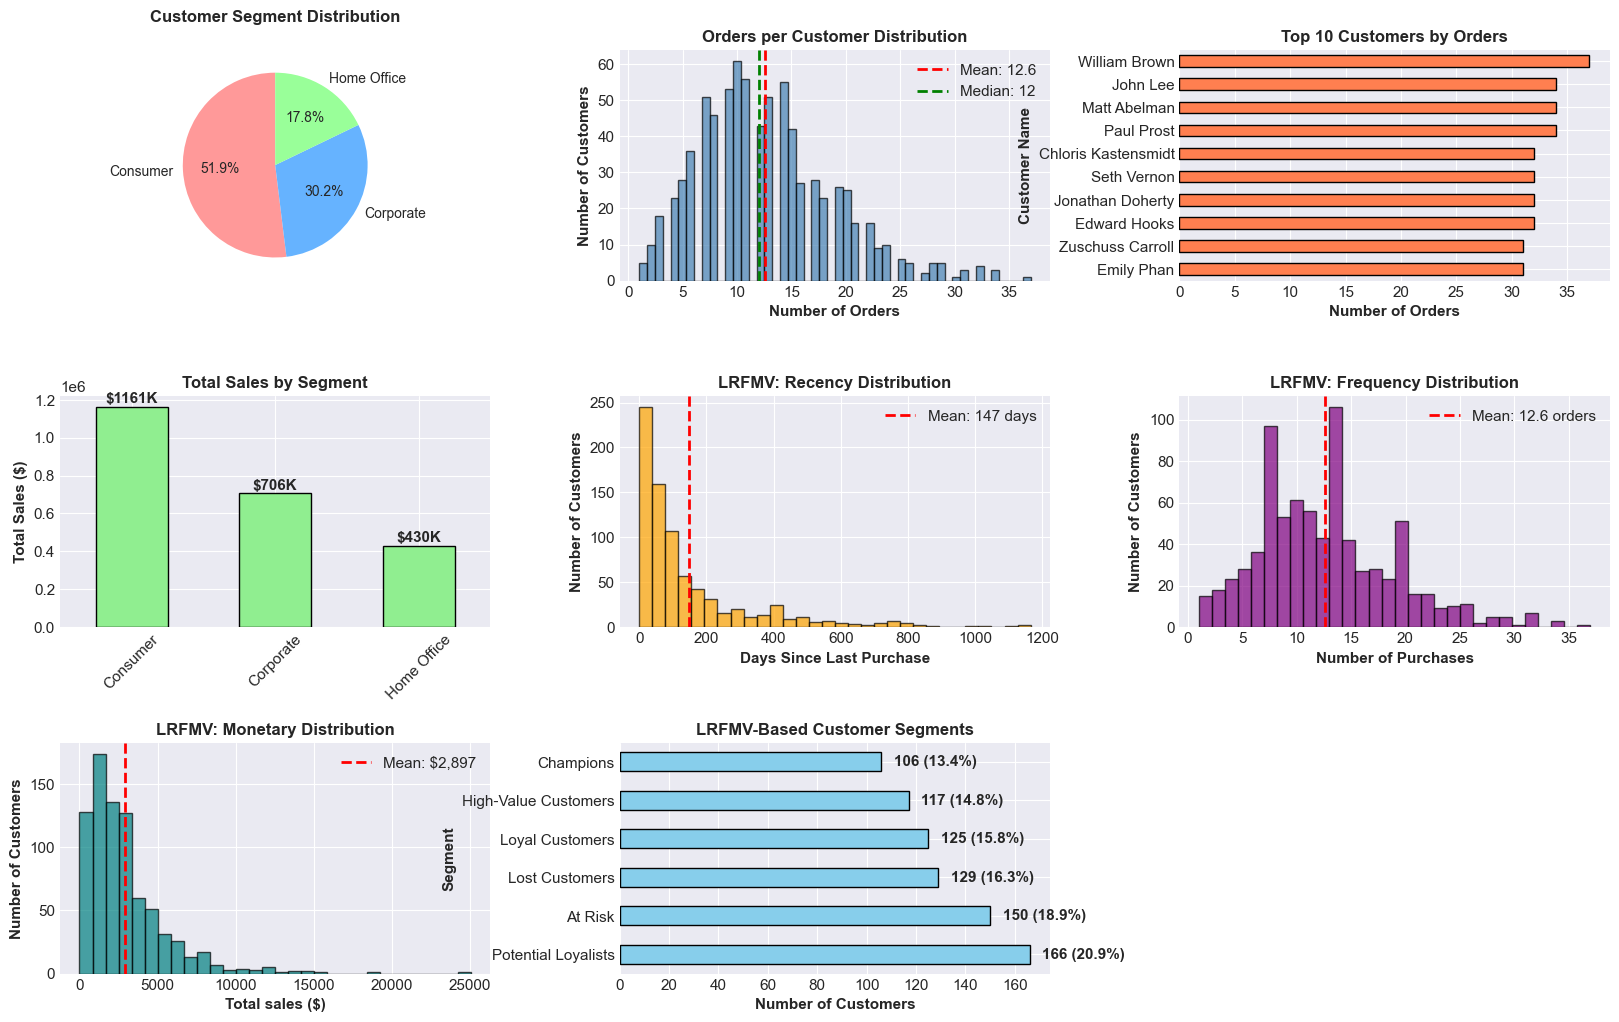

In [30]:
# Visualization: Customer Analysis
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.3)

# 1. Customer segment distribution (pie chart)
ax1 = fig.add_subplot(gs[0, 0])
segment_stats.plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'], textprops={'fontsize': 10})
ax1.set_title('Customer Segment Distribution', fontsize=12, pad=20)
ax1.set_ylabel('')

# 2. Orders per customer histogram
ax2 = fig.add_subplot(gs[0, 1])
orders_per_customer = data.groupby('Customer ID').size()
ax2.hist(orders_per_customer, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(orders_per_customer.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {orders_per_customer.mean():.1f}')
ax2.axvline(orders_per_customer.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {orders_per_customer.median():.0f}')
ax2.set_title('Orders per Customer Distribution', fontsize=12)
ax2.set_xlabel('Number of Orders', fontsize=11)
ax2.set_ylabel('Number of Customers', fontsize=11)
ax2.legend()

# 3. Top 10 customers by orders
ax3 = fig.add_subplot(gs[0, 2])
top_customers_orders.head(10).plot(kind='barh', ax=ax3, color='coral', edgecolor='black')
ax3.set_title('Top 10 Customers by Orders', fontsize=12)
ax3.set_xlabel('Number of Orders', fontsize=11)
ax3.set_ylabel('Customer Name', fontsize=11)
ax3.invert_yaxis()

# 4. Sales by segment
ax4 = fig.add_subplot(gs[1, 0])
segment_sales = data.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_sales.plot(kind='bar', ax=ax4, color='lightgreen', edgecolor='black')
ax4.set_title('Total Sales by Segment', fontsize=12)
ax4.set_xlabel('', fontsize=11)
ax4.set_ylabel('Total Sales ($)', fontsize=11)
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(segment_sales):
    ax4.text(i, v + 5000, f'${v/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

# 5. LRFMV Distribution - Recency
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(lrfmv_data['Recency'], bins=30, color='orange', alpha=0.7, edgecolor='black')
ax5.axvline(lrfmv_data['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {lrfmv_data["Recency"].mean():.0f} days')
ax5.set_title('LRFMV: Recency Distribution', fontsize=12)
ax5.set_xlabel('Days Since Last Purchase', fontsize=11)
ax5.set_ylabel('Number of Customers', fontsize=11)
ax5.legend()

# 6. LRFMV Distribution - Frequency
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(lrfmv_data['Frequency'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax6.axvline(lrfmv_data['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {lrfmv_data["Frequency"].mean():.1f} orders')
ax6.set_title('LRFMV: Frequency Distribution', fontsize=12)
ax6.set_xlabel('Number of Purchases', fontsize=11)
ax6.set_ylabel('Number of Customers', fontsize=11)
ax6.legend()

# 7. LRFMV Distribution - Monetary
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(lrfmv_data['Monetary'], bins=30, color='teal', alpha=0.7, edgecolor='black')
ax7.axvline(lrfmv_data['Monetary'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${lrfmv_data["Monetary"].mean():,.0f}')
ax7.set_title('LRFMV: Monetary Distribution', fontsize=12)
ax7.set_xlabel('Total sales ($)', fontsize=11)
ax7.set_ylabel('Number of Customers', fontsize=11)
ax7.legend()

# 8. LRFMV Segments
ax8 = fig.add_subplot(gs[2, 1])
segment_counts.plot(kind='barh', ax=ax8, color='skyblue', edgecolor='black')
ax8.set_title('LRFMV-Based Customer Segments', fontsize=12)
ax8.set_xlabel('Number of Customers', fontsize=11)
ax8.set_ylabel('Segment', fontsize=11)
for i, v in enumerate(segment_counts):
    ax8.text(v + 5, i, f'{v} ({v/len(lrfmv_data)*100:.1f}%)', va='center', fontweight='bold')
    
# plt.tight_layout()
# plt.savefig('customer_analysis.png', dpi=300, bbox_inches='tight')

**Key insights**

1️⃣ Customer Segment Distribution: Consumer(≈52%), Corporate(≈30%),Home Office(≈18%)of the customer base.

2️⃣ Orders per Customer Distribution: Distribution is right-skewed, Most customers place between 5–15 orders.
  - A small group of customers places significantly more orders, forming high-value customers.

3️⃣ Top 10 Customers by Orders: Top customers place 30–37 orders
   - These customers are high-loyalty, high-value clients and losing one of them could significantly impact revenue.

4️⃣ Total Sales by Segment: Consumer segment generates the highest revenue but Home Office generates the lowest sales.

5️⃣ Recency Distribution: Most customers have low recency values, indicating recent purchasing activity, the mean recency (~147 days).

6️⃣ Frequency Distribution: Most customers moderate purchase frequency, The average purchase frequency is 12.6 orders.

7️⃣ Monetary Distribution: distribution is right-skewed, with most customers spending low to moderate amounts, The mean monetary value is $2,897.

8️⃣ LRFMV-Based Customer Segments: The largest i**s Potential Loyalis**ts (20.9%), representing customers with strong engagement potential. **At Risk** (18.9%) and **Lost Customers** (16.3%) together form a significant portion of the customer base. **Champions** (13.4%) and **High-Value Customers** (14.8%), although smaller in number, represent the most valuable customers.

**Business Insights**

In [31]:
print(f"\n💡 Key Customer Insights for Segmentation:")

# Calculate key metrics
repeat_customers = orders_per_customer[orders_per_customer > 1].count() # Customers who purchased more than one order
one_time_customers = orders_per_customer[orders_per_customer == 1].count()  # Customers who purchased only one order.

# Customers in the top 25% of total spending (Monetary value) based on LRFMV analysis
high_value_customers = lrfmv_data[lrfmv_data['Monetary'] > lrfmv_data['Monetary'].quantile(0.75)]

print(f"\n   📊 Customer Behavior Patterns:")
print(f"      • Repeat Customers: {repeat_customers:,} ({repeat_customers/len(lrfmv_data)*100:.1f}%), Customers who purchased more than one order")
print(f"      • One-Time Customers: {one_time_customers:,} ({one_time_customers/len(lrfmv_data)*100:.1f}%), Customers who purchased only one order.")
print(f"      • High-Value Customers (top 25%): {len(high_value_customers):,}")
print(f"      • Average order per Customer: {lrfmv_data['Frequency'].mean():.1f} orders")

# Segment performance
print(f"\n   💰 Segment Profitability:")
for segment in data['Segment'].unique():
    seg_data = data[data['Segment'] == segment]
    avg_order = seg_data['Sales'].mean()
    total_profit = seg_data['Profit'].sum()
    profit_margin = (total_profit / seg_data['Sales'].sum()) * 100
    print(f"      • {segment}:")
    print(f"        - Average Order Value: ${avg_order:.2f}")
    print(f"        - Total Profit: ${total_profit:,.2f}")
    print(f"        - Profit Margin: {profit_margin:.2f}%")


💡 Key Customer Insights for Segmentation:

   📊 Customer Behavior Patterns:
      • Repeat Customers: 788 (99.4%), Customers who purchased more than one order
      • One-Time Customers: 5 (0.6%), Customers who purchased only one order.
      • High-Value Customers (top 25%): 198
      • Average order per Customer: 12.6 orders

   💰 Segment Profitability:
      • Consumer:
        - Average Order Value: $223.73
        - Total Profit: $134,119.21
        - Profit Margin: 11.55%
      • Corporate:
        - Average Order Value: $233.82
        - Total Profit: $91,979.13
        - Profit Margin: 13.03%
      • Home Office:
        - Average Order Value: $240.97
        - Total Profit: $60,298.68
        - Profit Margin: 14.03%


### (3) Geographical Analysis

In [32]:
print(f"\n🌍 Geographical Coverage:")
print(f"   • Countries: 1 (United States)")
print(f"   • Regions: {data['Region'].nunique()}")
print(f"   • States: {data['State'].nunique()}")
print(f"   • Cities: {data['City'].nunique()}")


🌍 Geographical Coverage:
   • Countries: 1 (United States)
   • Regions: 4
   • States: 49
   • Cities: 531


In [33]:
# Regional distribution
print(f"\n📊 Orders by Region:")
region_stats = data['Region'].value_counts().sort_values(ascending=False)
for region, count in region_stats.items():
    pct = count / len(data) * 100
    print(f"   • {region:<10} : {count:5,} orders ({pct:5.1f}%)")

# Top states
print(f"\n📊 Top 10 States by Order Volume:")
top_states = data['State'].value_counts().head(10)
for i, (state, count) in enumerate(top_states.items(), 1):
    state_sales = data[data['State'] == state]['Sales'].sum()
    print(f"   {i:2d}. {state:<20} → {count:4,} orders, ${state_sales:,.2f} sales")

# Top cities
print(f"\n📊 Top 10 Cities by Order Volume:")
top_cities = data['City'].value_counts().head(10)
for i, (city, count) in enumerate(top_cities.items(), 1):
    city_sales = data[data['City'] == city]['Sales'].sum()
    city_state = data[data['City'] == city]['State'].iloc[0]
    print(f"   {i:2d}. {city:<20} ({city_state}) → {count:4,} orders, ${city_sales:,.2f} sales")


📊 Orders by Region:
   • West       : 3,203 orders ( 32.0%)
   • East       : 2,848 orders ( 28.5%)
   • Central    : 2,323 orders ( 23.2%)
   • South      : 1,620 orders ( 16.2%)

📊 Top 10 States by Order Volume:
    1. California           → 2,001 orders, $457,687.63 sales
    2. New York             → 1,128 orders, $310,876.27 sales
    3. Texas                →  985 orders, $170,188.05 sales
    4. Pennsylvania         →  587 orders, $116,511.91 sales
    5. Washington           →  506 orders, $138,641.27 sales
    6. Illinois             →  492 orders, $80,166.10 sales
    7. Ohio                 →  469 orders, $78,258.14 sales
    8. Florida              →  383 orders, $89,473.71 sales
    9. Michigan             →  255 orders, $76,269.61 sales
   10. North Carolina       →  249 orders, $55,603.16 sales

📊 Top 10 Cities by Order Volume:
    1. New York City        (New York) →  915 orders, $256,368.16 sales
    2. Los Angeles          (California) →  747 orders, $175,851.34 sale

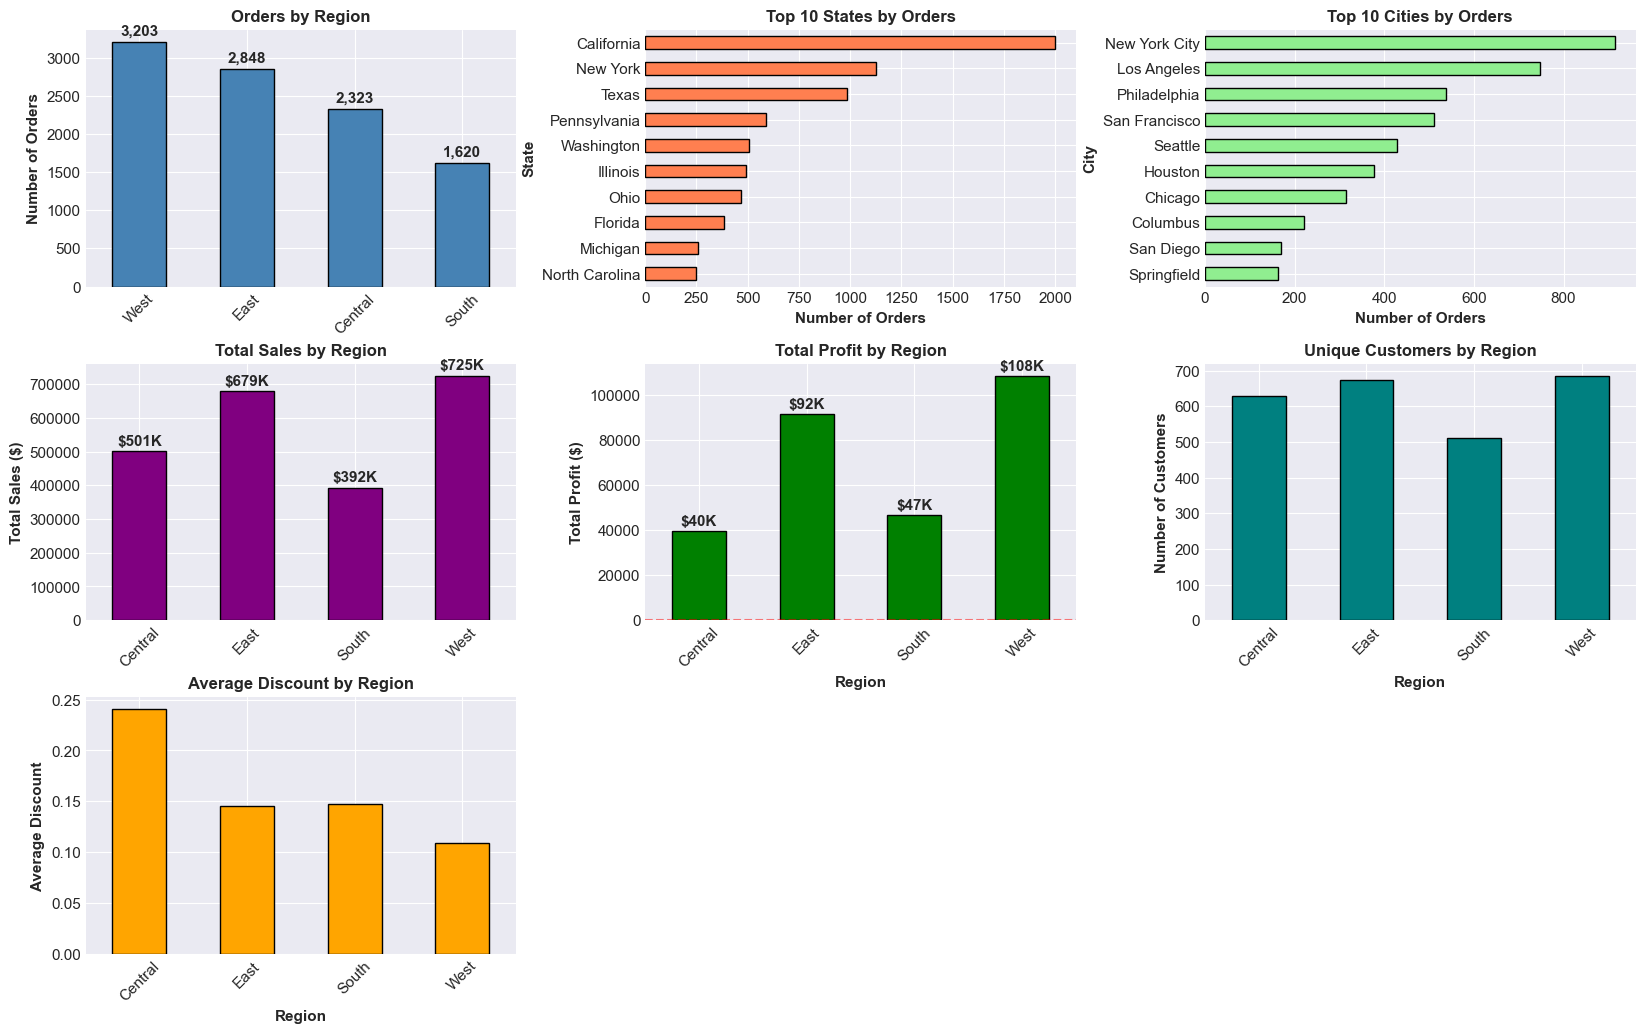

In [34]:
# Regional performance
regional_performance = data.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Customers=('Customer ID', 'nunique'),
    Avg_Discount=('Discount', 'mean'))

# Visualization: Geographical Analysis
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Orders by region
ax1 = fig.add_subplot(gs[0, 0])
region_stats.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Orders by Region', fontsize=12)
ax1.set_xlabel('', fontsize=11)
ax1.set_ylabel('Number of Orders', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(region_stats):
    ax1.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# 2. Top 10 states
ax2 = fig.add_subplot(gs[0, 1])
top_states.plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Top 10 States by Orders', fontsize=12)
ax2.set_xlabel('Number of Orders', fontsize=11)
ax2.set_ylabel('State', fontsize=11)
ax2.invert_yaxis()

# 3. Top 10 cities
ax3 = fig.add_subplot(gs[0, 2])
top_cities.plot(kind='barh', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Top 10 Cities by Orders', fontsize=12)
ax3.set_xlabel('Number of Orders', fontsize=11)
ax3.set_ylabel('City', fontsize=11)
ax3.invert_yaxis()

# 4. Sales by region
ax4 = fig.add_subplot(gs[1, 0])
regional_performance['Total_Sales'].plot(kind='bar', ax=ax4, color='purple', edgecolor='black')
ax4.set_title('Total Sales by Region', fontsize=12)
ax4.set_xlabel('', fontsize=11)
ax4.set_ylabel('Total Sales ($)', fontsize=11)
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(regional_performance['Total_Sales']):
    ax4.text(i, v + 10000, f'${v/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

# 5. Profit by region
ax5 = fig.add_subplot(gs[1, 1])
regional_performance['Total_Profit'].plot(kind='bar', ax=ax5, color='green', edgecolor='black')
ax5.set_title('Total Profit by Region', fontsize=12)
ax5.set_xlabel('Region', fontsize=11)
ax5.set_ylabel('Total Profit ($)', fontsize=11)
ax5.tick_params(axis='x', rotation=45)
ax5.axhline(0, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(regional_performance['Total_Profit']):
    ax5.text(i, v + 1000, f'${v/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

# 6. Customers by region
ax6 = fig.add_subplot(gs[1, 2])
regional_performance['Customers'].plot(kind='bar', ax=ax6, color='teal', edgecolor='black')
ax6.set_title('Unique Customers by Region', fontsize=12)
ax6.set_xlabel('Region', fontsize=11)
ax6.set_ylabel('Number of Customers', fontsize=11)
ax6.tick_params(axis='x', rotation=45)

# 7. Average discount by region
ax7 = fig.add_subplot(gs[2, 0])
regional_performance['Avg_Discount'].plot(kind='bar', ax=ax7, color='orange', edgecolor='black')
ax7.set_title('Average Discount by Region', fontsize=12)
ax7.set_xlabel('Region', fontsize=11)
ax7.set_ylabel('Average Discount', fontsize=11)
ax7.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.savefig('Geographical_Analysis.png', dpi=300, bbox_inches='tight')

**Key insights**

1️⃣ Orders by Region: West is highest orders, South has lowest order.

2️⃣ Top 10 States by Orders: ranking the top 5 U.S. states by orders. California, New York and Texas show strong demand.

3️⃣ Top 10 Cities by Orders: New York and Los Angeles Cities are strong orders.

4️⃣ Total Sales by Region: West region generates the highest revenue, despite similar order counts to East.

5️⃣ Total Profit by Region: West leads highest profit (≈ $108K).

6️⃣ Unique Customers by Region: West has the largest customer base. East and Central also have strong customer counts.

6️⃣ Average Discount by Region: Central offers the highest(~24%).

**Overall Business Interpretation**
- The West region is the strongest performer across sales, profit, and customer base, with minimal discounts.
- The East region performs well but may optimize profits further.
- The Central region relies heavily on discounts (4.0% avg discount), which could impact margins.
- The South region shows the weakest performance

### (4) Product Analysis (Foundation for Recommendations)

In [35]:
# Number of Category and Products
print(f"\n📦 Product Overview:")
print(f"   - Product Categories: {data['Category'].nunique()}")
print(f"   - Unique Product Names: {data['Product Name'].nunique():,}")


📦 Product Overview:
   - Product Categories: 3
   - Unique Product Names: 17


In [36]:
# Category distribution
print(f"\n📊 Orders by Category:")
category_stats = data['Category'].value_counts().sort_values(ascending=False)
for category, count in category_stats.items():
    pct = count / len(data) * 100
    cat_sales = data[data['Category'] == category]['Sales'].sum()
    print(f"   • {category:<20} : {count:5,} orders ({pct:5.1f}%), ${cat_sales:,.2f} sales")

# Product type distribution
print(f"\n📊 Top 10 Product Types by Order Volume:")
product_stats = data['Product Name'].value_counts().head(10)
for i, (product, count) in enumerate(product_stats.items(), 1):
    prod_sales = data[data['Product Name'] == product]['Sales'].sum()
    prod_profit = data[data['Product Name'] == product]['Profit'].sum()
    print(f"   {i:2d}. {product:<20} → {count:4,} orders, ${prod_sales:>10,.2f} sales, ${prod_profit:>10,.2f} profit")


📊 Orders by Category:
   • Office Supplies      : 6,026 orders ( 60.3%), $719,047.03 sales
   • Furniture            : 2,121 orders ( 21.2%), $741,999.80 sales
   • Technology           : 1,847 orders ( 18.5%), $836,154.03 sales

📊 Top 10 Product Types by Order Volume:
    1. Binders              → 1,523 orders, $203,412.73 sales, $ 30,221.76 profit
    2. Paper                → 1,370 orders, $ 78,479.21 sales, $ 34,053.57 profit
    3. Furnishings          →  957 orders, $ 91,705.16 sales, $ 13,059.14 profit
    4. Phones               →  889 orders, $330,007.05 sales, $ 44,515.73 profit
    5. Storage              →  846 orders, $223,843.61 sales, $ 21,278.83 profit
    6. Art                  →  796 orders, $ 27,118.79 sales, $  6,527.79 profit
    7. Accessories          →  775 orders, $167,380.32 sales, $ 41,936.64 profit
    8. Chairs               →  617 orders, $328,449.10 sales, $ 26,590.17 profit
    9. Appliances           →  466 orders, $107,532.16 sales, $ 18,138.01 profi

In [37]:
# Product profitability analysis
print(f"\n🏆 Top 10 Most Profitable Products:")
product_profitability = data.groupby('Product Name').agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Order ID': 'count'}).sort_values('Profit', ascending=False)
product_profitability['Profit_Margin'] = (product_profitability['Profit'] / product_profitability['Sales'] * 100)

for i, (product, row) in enumerate(product_profitability.head(10).iterrows(), 1):
    print(f"   {i:2d}. {product:<20} → Profit: ${row['Profit']:>10,.2f}, " + 
          f"Margin: {row['Profit_Margin']:>5.1f}%, Orders: {int(row['Order ID']):>4,}")

print(f"\n📉 Top 10 Loss-Making Products:")
for i, (product, row) in enumerate(product_profitability.tail(10).iterrows(), 1):
    print(f"   {i:2d}. {product:<20} → Loss: ${row['Profit']:>10,.2f}, " + 
          f"Margin: {row['Profit_Margin']:>5.1f}%, Orders: {int(row['Order ID']):>4,}")


🏆 Top 10 Most Profitable Products:
    1. Copiers              → Profit: $ 55,617.82, Margin:  37.2%, Orders:   68
    2. Phones               → Profit: $ 44,515.73, Margin:  13.5%, Orders:  889
    3. Accessories          → Profit: $ 41,936.64, Margin:  25.1%, Orders:  775
    4. Paper                → Profit: $ 34,053.57, Margin:  43.4%, Orders: 1,370
    5. Binders              → Profit: $ 30,221.76, Margin:  14.9%, Orders: 1,523
    6. Chairs               → Profit: $ 26,590.17, Margin:   8.1%, Orders:  617
    7. Storage              → Profit: $ 21,278.83, Margin:   9.5%, Orders:  846
    8. Appliances           → Profit: $ 18,138.01, Margin:  16.9%, Orders:  466
    9. Furnishings          → Profit: $ 13,059.14, Margin:  14.2%, Orders:  957
   10. Envelopes            → Profit: $  6,964.18, Margin:  42.3%, Orders:  254

📉 Top 10 Loss-Making Products:
    1. Appliances           → Loss: $ 18,138.01, Margin:  16.9%, Orders:  466
    2. Furnishings          → Loss: $ 13,059.14, Mar

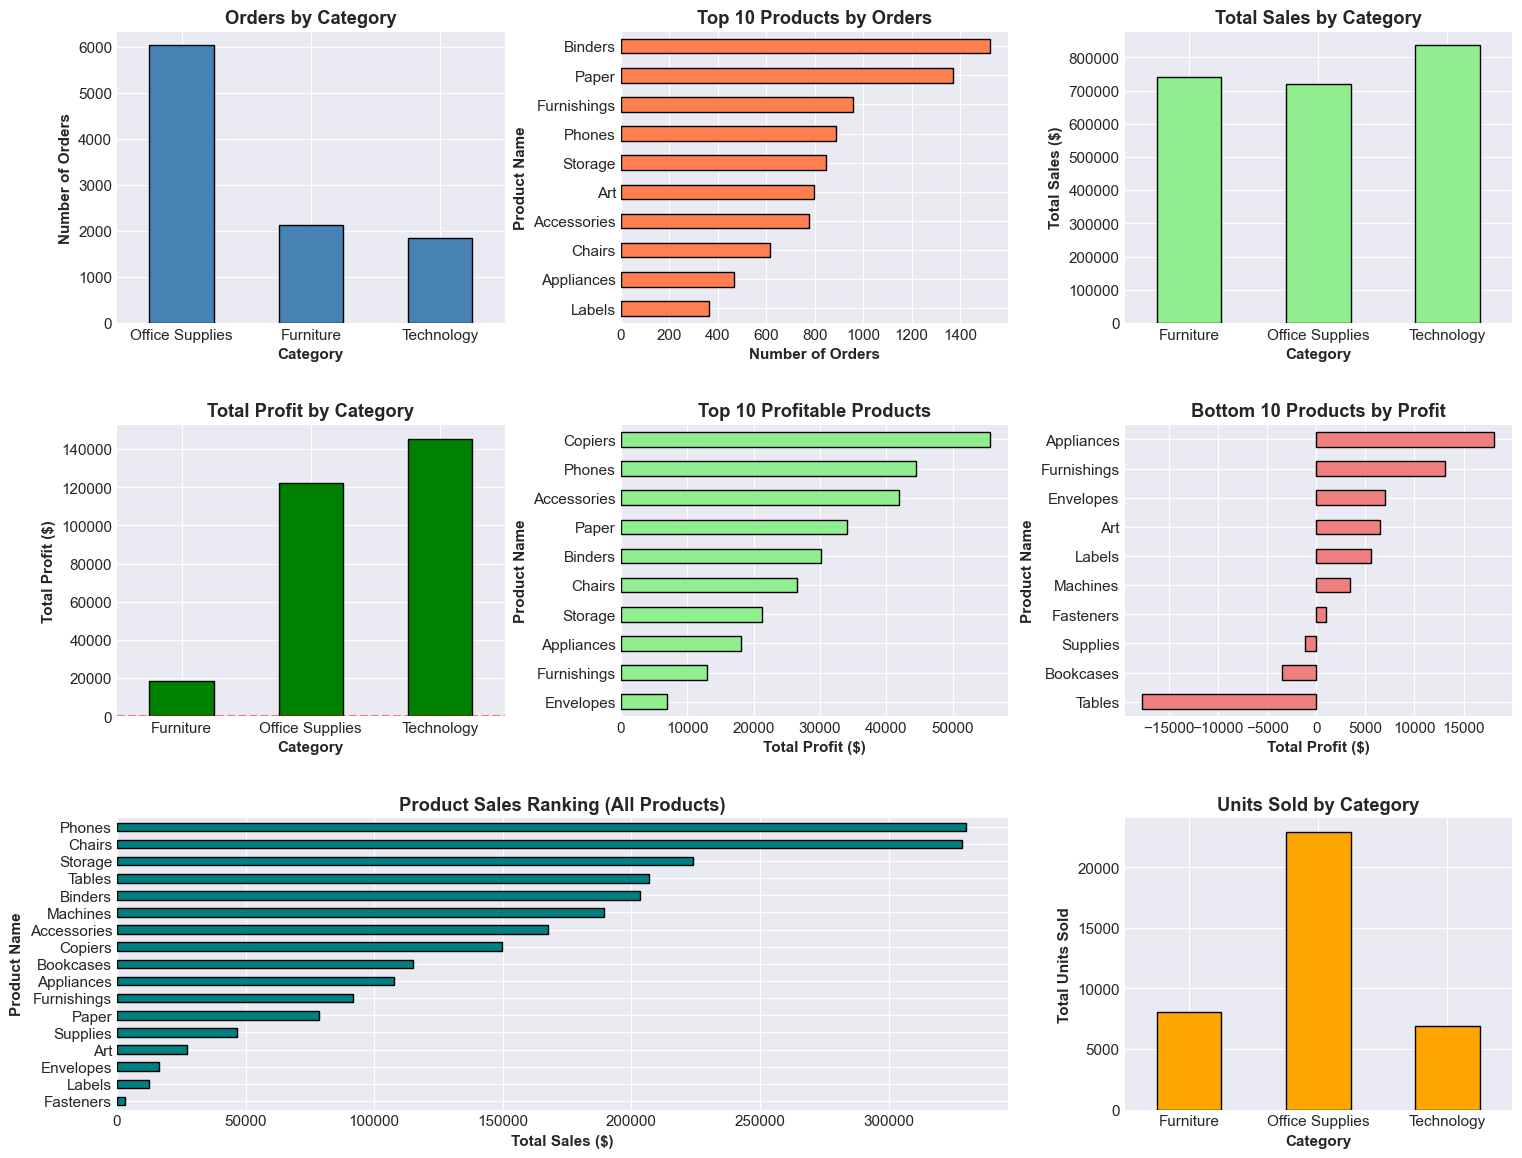

In [38]:
# category performance
category_performance = data.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Orders=('Order ID', 'count'))

product_sales_all = (data.groupby('Product Name')['Sales'].sum().sort_values(ascending=True))

# Visualization Dashboard
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1: Orders by Category 
ax1 = fig.add_subplot(gs[0, 0])
category_stats.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Orders by Category')
ax1.set_ylabel('Number of Orders')
ax1.tick_params(axis='x', rotation=0)

# 2: Top Products by Orders 
ax2 = fig.add_subplot(gs[0, 1])
product_stats.plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Top 10 Products by Orders')
ax2.set_xlabel('Number of Orders')
ax2.invert_yaxis()

# 3: Total Sales by Category
ax3 = fig.add_subplot(gs[0, 2])
category_performance['Total_Sales'].plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Total Sales by Category')
ax3.set_ylabel('Total Sales ($)')
ax3.tick_params(axis='x', rotation=0)

# 4: Total Profit by Category 
ax4 = fig.add_subplot(gs[1, 0])
category_performance['Total_Profit'].plot(kind='bar', ax=ax4, color='green', edgecolor='black')
ax4.set_title('Total Profit by Category')
ax4.set_ylabel('Total Profit ($)')
ax4.axhline(0, color='red', linestyle='--', alpha=0.5)
ax4.tick_params(axis='x', rotation=0)

# 5: Top 10 Profitable Products 
ax5 = fig.add_subplot(gs[1, 1])
product_profitability.head(10)['Profit'].plot(kind='barh', ax=ax5, color='lightgreen', edgecolor='black')
ax5.set_title('Top 10 Profitable Products')
ax5.set_xlabel('Total Profit ($)')
ax5.invert_yaxis()

# 6: Bottom 10 Products by Profit 
ax6 = fig.add_subplot(gs[1, 2])
product_profitability.tail(10)['Profit'].plot(kind='barh', ax=ax6, color='lightcoral', edgecolor='black')
ax6.set_title('Bottom 10 Products by Profit')
ax6.set_xlabel('Total Profit ($)')
ax6.invert_yaxis()

# 7: Product Sales Ranking 
ax7 = fig.add_subplot(gs[2, 0:2])
product_sales_all.plot(kind='barh', ax=ax7, color='teal', edgecolor='black')
ax7.set_title('Product Sales Ranking (All Products)')
ax7.set_xlabel('Total Sales ($)')

# 8: Units Sold by Category 
ax8 = fig.add_subplot(gs[2, 2])
category_performance['Units_Sold'].plot(kind='bar', ax=ax8, color='orange', edgecolor='black')
ax8.set_title('Units Sold by Category')
ax8.set_ylabel('Total Units Sold')
ax8.tick_params(axis='x', rotation=0)

plt.tight_layout()
# plt.savefig('product_analysis.png', dpi=300, bbox_inches='tight')

**Key Insights**

1️⃣ Orders by Category: **Office Supplies** are high-frequency, low-value purchases, which customers buy repeatedly. **Furniture and Technology** are less frequently ordered due to: Higher prices.

2️⃣ Orders by Product Name: Products with low price and frequent usage (like binders and paper) generate more orders, while expensive items are ordered less often.

3️⃣ Total Sales by Category: High-value products (Technology) generate more revenue with fewer orders. Office Supplies  having the most orders, has lower total sales.

4️⃣ Total profit by Category: High-value products (Technology) generate more revenue with fewer orders. Furniture  has lower total profit.

5️⃣ Top 10 profitable products: These products either have high margins, strong demand, or both. They represent the core profit-generating items

6️⃣ Botton 10 profitable products: These items reduce overall profitability due to high discounting

7️⃣ Products sales ranking: Phones generate the highest sales. High-priced products dominate revenue, even if their order count is not the highest.

8️⃣ Unit sold per category: Office Supplies is a volume-based business, while Technology generates profit efficiency.

**Business Insights**

In [39]:
print(f"\n💡 Key Product Insights for Recommendation Systems:")

# Category insights
best_category_profit = category_performance['Total_Profit'].idxmax()
best_category_volume = category_performance['Orders'].idxmax()

print(f"\n   💰 Category Insights:")
print(f"      • Most Profitable: {best_category_profit}")
print(f"      • Highest Volume Quantity: {best_category_volume}")
print(f"      • Revenue: {category_performance['Total_Sales'].max() / category_performance['Total_Sales'].sum() * 100:.1f}% in top category")


💡 Key Product Insights for Recommendation Systems:

   💰 Category Insights:
      • Most Profitable: Technology
      • Highest Volume Quantity: Office Supplies
      • Revenue: 36.4% in top category


### (5) Sales and Financial Analysis

In [40]:
print(f"\n💰 Overall Financial Performance:")
print(f"   • Total Revenue: ${data['Sales'].sum():,.2f}")
print(f"   • Total Profit: ${data['Profit'].sum():,.2f}")
print(f"   • Total Discount Given: ${(data['Sales'] * data['Discount']).sum():,.2f}")
print(f"   • Overall Profit Margin: {(data['Profit'].sum() / data['Sales'].sum() * 100):.2f}%")
print(f"   • Total Units Sold: {data['Quantity'].sum():,}")

print(f"\n📊 Sales Statistics:")
print(f"   • Average Order Value: ${data['Sales'].mean():.2f}")
print(f"   • Median Order Value: ${data['Sales'].median():.2f}")
print(f"   • Minimum Order: ${data['Sales'].min():.2f}")
print(f"   • Maximum Order: ${data['Sales'].max():,.2f}")

print(f"\n💵 Profit Statistics:")
print(f"   • Average Profit per Order: ${data['Profit'].mean():.2f}")
print(f"   • Median Profit per Order: ${data['Profit'].median():.2f}")
print(f"   • Best Single Order Profit: ${data['Profit'].max():,.2f}")
print(f"   • Worst Single Order Loss: ${data['Profit'].min():,.2f}")

print(f"\n📉 Discount Statistics:")
print(f"   • Average Discount Rate: {data['Discount'].mean():.2%}")
print(f"   • Median Discount Rate: {data['Discount'].median():.2%}")
print(f"   • Maximum Discount Given: {data['Discount'].max():.2%}")
print(f"   • Orders with Discount: {(data['Discount'] > 0).sum():,} ({(data['Discount'] > 0).sum() / len(data) * 100:.1f}%)")
print(f"   • Orders without Discount: {(data['Discount'] == 0).sum():,} ({(data['Discount'] == 0).sum() / len(data) * 100:.1f}%)")

print(f"\n📦 Quantity Statistics:")
print(f"   • Average Units per Order: {data['Quantity'].mean():.2f}")
print(f"   • Median Units per Order: {data['Quantity'].median():.0f}")
print(f"   • Maximum Units in Single Order: {data['Quantity'].max()}")

# Profitability analysis
profitable_orders = data[data['Profit'] > 0]
unprofitable_orders = data[data['Profit'] <= 0]

print(f"\n💰 Profitability Breakdown:")
print(f"   • Profitable Orders: {len(profitable_orders):,} ({len(profitable_orders)/len(data)*100:.1f}%)")
print(f"   • Unprofitable Orders: {len(unprofitable_orders):,} ({len(unprofitable_orders)/len(data)*100:.1f}%)")
print(f"   • Revenue(sales) from Profitable Orders: ${profitable_orders['Sales'].sum():,.2f}")
print(f"   • Revenue(sales) from Unprofitable Orders: ${unprofitable_orders['Sales'].sum():,.2f}")
print(f"   • Total Profit from Profitable Orders: ${profitable_orders['Profit'].sum():,.2f}")
print(f"   • Total Loss from Unprofitable Orders: ${unprofitable_orders['Profit'].sum():,.2f}")


💰 Overall Financial Performance:
   • Total Revenue: $2,297,200.86
   • Total Profit: $286,397.02
   • Total Discount Given: $322,582.13
   • Overall Profit Margin: 12.47%
   • Total Units Sold: 37,873

📊 Sales Statistics:
   • Average Order Value: $229.86
   • Median Order Value: $54.49
   • Minimum Order: $0.44
   • Maximum Order: $22,638.48

💵 Profit Statistics:
   • Average Profit per Order: $28.66
   • Median Profit per Order: $8.67
   • Best Single Order Profit: $8,399.98
   • Worst Single Order Loss: $-6,599.98

📉 Discount Statistics:
   • Average Discount Rate: 15.62%
   • Median Discount Rate: 20.00%
   • Maximum Discount Given: 80.00%
   • Orders with Discount: 5,196 (52.0%)
   • Orders without Discount: 4,798 (48.0%)

📦 Quantity Statistics:
   • Average Units per Order: 3.79
   • Median Units per Order: 3
   • Maximum Units in Single Order: 14

💰 Profitability Breakdown:
   • Profitable Orders: 8,058 (80.6%)
   • Unprofitable Orders: 1,936 (19.4%)
   • Revenue(sales) from P

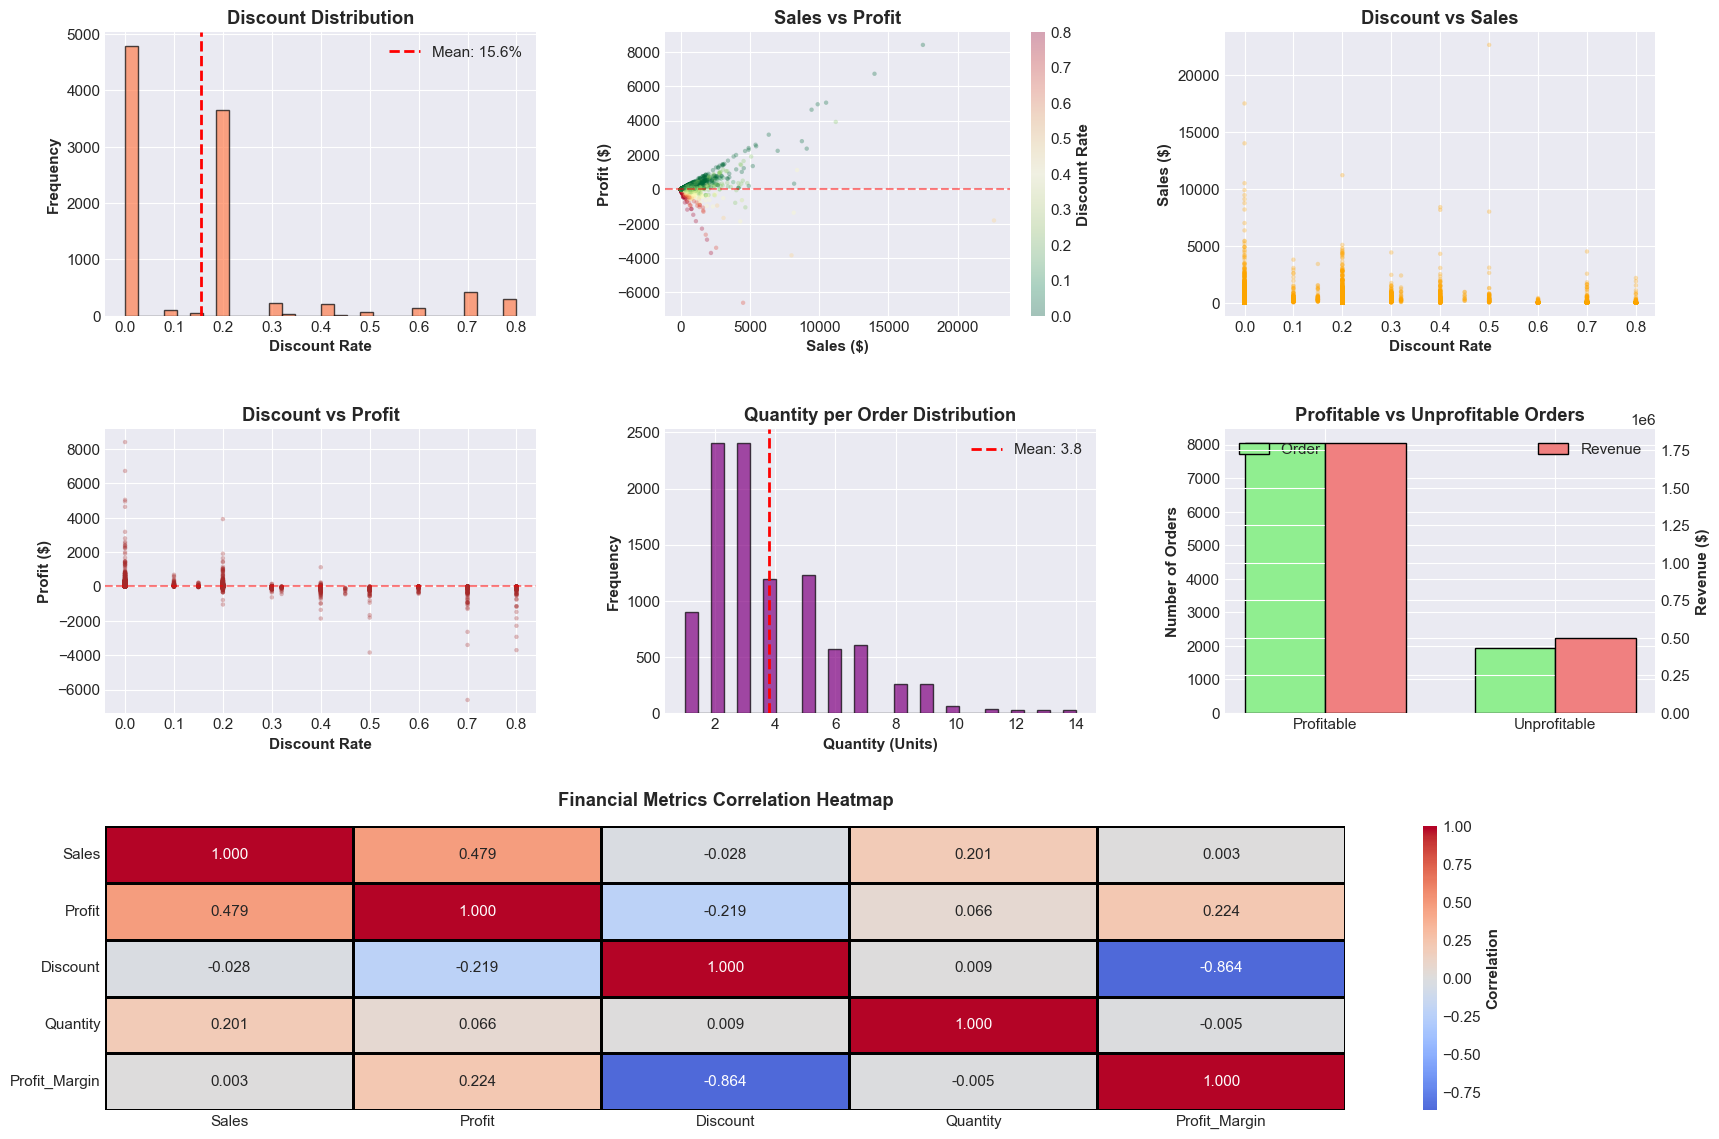

In [41]:
# Correlation matrix
correlation_features = ['Sales','Profit','Discount','Quantity','Profit_Margin']
correlation_matrix = data[correlation_features].corr()

# Financial Analysis Dashboard
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Discount distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(data['Discount'], bins=30, color='coral', alpha=0.7, edgecolor='black')
ax1.axvline(data['Discount'].mean(), color='red', linestyle='--', linewidth=2,label=f'Mean: {data["Discount"].mean():.1%}')
ax1.set_title('Discount Distribution')
ax1.set_xlabel('Discount Rate')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Sales vs Profit
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(data['Sales'], data['Profit'], alpha=0.3, s=10,c=data['Discount'], cmap='RdYlGn_r', edgecolor='none')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Sales vs Profit')
ax2.set_xlabel('Sales ($)')
ax2.set_ylabel('Profit ($)')
plt.colorbar(scatter, ax=ax2, label='Discount Rate')

# 3. Discount vs Sales
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(data['Discount'], data['Sales'], alpha=0.3, s=10, color='orange', edgecolor='none')
ax3.set_title('Discount vs Sales')
ax3.set_xlabel('Discount Rate')
ax3.set_ylabel('Sales ($)')

# 4. Discount vs Profit
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(data['Discount'], data['Profit'], alpha=0.3, s=10, color='brown', edgecolor='none')
ax4.axhline(0, color='red', linestyle='--', alpha=0.5)
ax4.set_title('Discount vs Profit')
ax4.set_xlabel('Discount Rate')
ax4.set_ylabel('Profit ($)')

# 5. Quantity distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(data['Quantity'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax5.axvline(data['Quantity'].mean(), color='red', linestyle='--', linewidth=2,label=f'Mean: {data["Quantity"].mean():.1f}')
ax5.set_title('Quantity per Order Distribution')
ax5.set_xlabel('Quantity (Units)')
ax5.set_ylabel('Frequency')
ax5.legend()

# 6. Profitable vs Unprofitable orders
ax6 = fig.add_subplot(gs[1, 2])
profit_status_data = pd.DataFrame({'Status': ['Profitable', 'Unprofitable'],
    'Count': [len(profitable_orders), len(unprofitable_orders)],
    'Revenue': [profitable_orders['Sales'].sum(), unprofitable_orders['Sales'].sum()]})
x = np.arange(len(profit_status_data))
width = 0.35
ax6.bar(x - width/2, profit_status_data['Count'], width,label='Order Count', color='lightgreen', edgecolor='black')
ax6_twin = ax6.twinx()
ax6_twin.bar(x + width/2, profit_status_data['Revenue'], width,label='Revenue', color='lightcoral', edgecolor='black')
ax6.set_xticks(x)
ax6.set_xticklabels(profit_status_data['Status'])
ax6.set_title('Profitable vs Unprofitable Orders')
ax6.set_ylabel('Number of Orders')
ax6_twin.set_ylabel('Revenue ($)')
ax6.legend(loc='upper left')
ax6_twin.legend(loc='upper right')

# 7. Correlation Heatmap (FULL WIDTH)
ax7 = fig.add_subplot(gs[2, :])
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',center=0, ax=ax7, cbar_kws={'label': 'Correlation'},linewidths=1, linecolor='black')
ax7.set_title('Financial Metrics Correlation Heatmap', pad=15)

plt.tight_layout()
plt.show()

**Key Insights**

1️⃣ Discount Distribution: Most transactions have low or zero discount. High discounts (50–80%) occur but are much less frequent.Discounts are used strategically, not randomly.

2️⃣ Sales vs Profit Relationship: a general positive trend: higher sales tend to yield higher profit. High sales do not guarantee profitability.
     
3️⃣ Discount vs Sales Relationship: High sales can occur with little or no discount.

4️⃣ Discount vs Profit Relationship: As discount increases, profit generally decreases. Low or zero discounts show positive profits.
                                       
5️⃣ Quantity per Order Distribution: Mean quantity ≈ 3.8 units. Most orders contain 2–4 units. Very few orders contain large quantities (>8 units). Distribution is right-skewed.

6️⃣ Profitable vs Unprofitable Orders: Profitable orders are much more numerous. Unprofitable orders are fewer but still contribute significant revenue.

7️⃣ Financial Metrics Correlation Heatmap: 
| Relationship                 | Value                    | Meaning                                  |
| ---------------------------- | ------------------------ | ---------------------------------------- |
| **Sales ↔ Profit**           | **+0.479**               | Higher sales often lead to higher profit |
| **Profit ↔ Discount**        | **−0.219**               | More discount → lower profit             |
| **Discount ↔ Profit Margin** | **−0.864 (very strong)** | Discounts severely damage margin         |
| **Quantity ↔ Sales**         | +0.201                   | Larger orders slightly increase sales    |
| **Quantity ↔ Profit**        | +0.066                   | Weak effect on profit                    |
| **Sales ↔ Profit Margin**    | ~0                       | Revenue does not guarantee good margins  |



**Overall Business Insights**
- Revenue growth and profit growth are not the same.
- Discounts must be carefully controlled, as they strongly affect profit.
- Large sales require better margin management, not just volume focus.
- Data-driven pricing and discount policies can significantly improve profitability.

### (6) Shipping mode Analysis

In [42]:
print(f"\n📦 Shipping Mode Distribution:")
ship_mode_stats = data['Ship Mode'].value_counts().sort_values(ascending=False)
for mode, count in ship_mode_stats.items():
    pct = count / len(data) * 100
    mode_sales = data[data['Ship Mode'] == mode]['Sales'].sum()
    avg_shipping = data[data['Ship Mode'] == mode]['Shipping_Days'].mean()
    print(f"   • {mode:<20} : {count:5,} orders ({pct:5.1f}%), ${mode_sales:>12,.2f} sales, {avg_shipping:.1f} days avg")

print(f"\n⏱️ Shipping Time Analysis:")
print(f"   • Average Shipping Days: {data['Shipping_Days'].mean():.2f}")
print(f"   • Median Shipping Days: {data['Shipping_Days'].median():.0f}")
print(f"   • Fastest Delivery: {data['Shipping_Days'].min()} days")
print(f"   • Slowest Delivery: {data['Shipping_Days'].max()} days")


📦 Shipping Mode Distribution:
   • Standard Class       : 5,968 orders ( 59.7%), $1,358,215.74 sales, 5.0 days avg
   • Second Class         : 1,945 orders ( 19.5%), $  459,193.57 sales, 3.2 days avg
   • First Class          : 1,538 orders ( 15.4%), $  351,428.42 sales, 2.2 days avg
   • Same Day             :   543 orders (  5.4%), $  128,363.12 sales, 0.0 days avg

⏱️ Shipping Time Analysis:
   • Average Shipping Days: 3.96
   • Median Shipping Days: 4
   • Fastest Delivery: 0 days
   • Slowest Delivery: 7 days


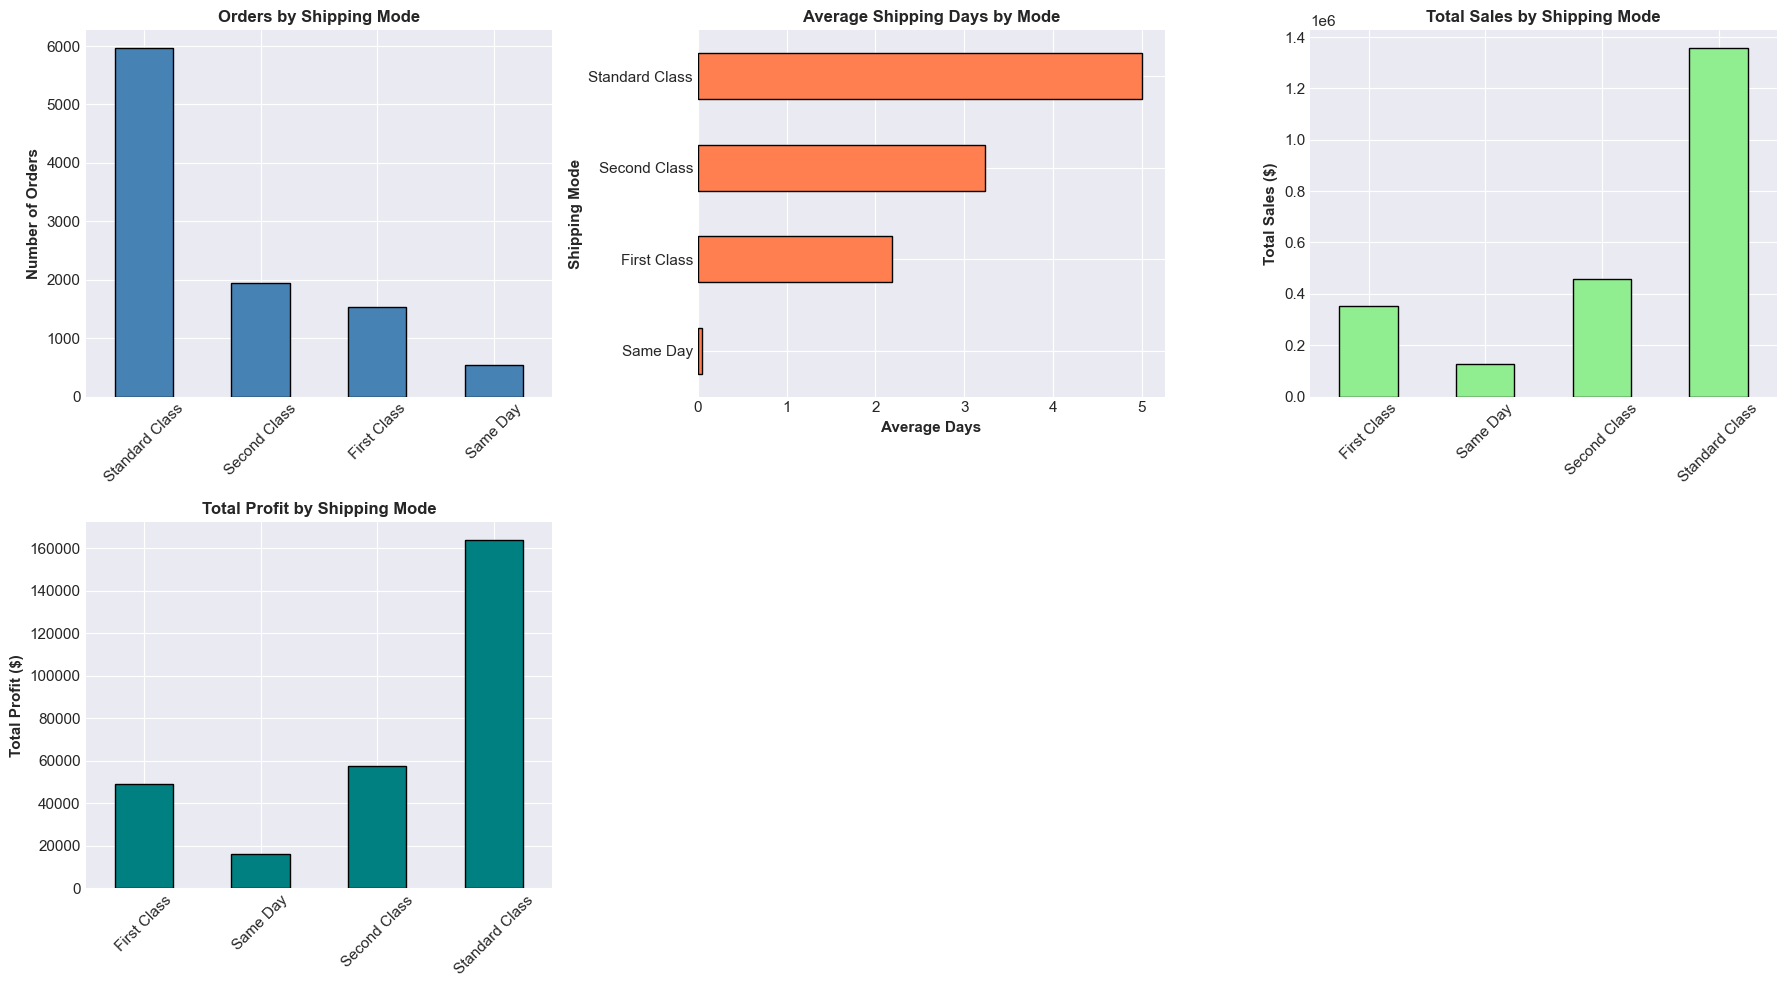

In [43]:
# Shipping performance metrics
shipping_performance = data.groupby('Ship Mode').agg(
    Avg_Days=('Shipping_Days', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'))

# Visualization: Shipping Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Orders by shipping mode
ship_mode_stats.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Orders by Shipping Mode', fontsize=12)
axes[0, 0].set_xlabel('', fontsize=11)
axes[0, 0].set_ylabel('Number of Orders', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average shipping days by mode
shipping_performance['Avg_Days'].sort_values().plot(kind='barh', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Shipping Days by Mode', fontsize=12)
axes[0, 1].set_xlabel('Average Days', fontsize=11)
axes[0, 1].set_ylabel('Shipping Mode', fontsize=11)

# 3. Sales by shipping mode
shipping_performance['Total_Sales'].plot(kind='bar', ax=axes[0, 2], color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Total Sales by Shipping Mode', fontsize=12)
axes[0, 2].set_xlabel('', fontsize=11)
axes[0, 2].set_ylabel('Total Sales ($)', fontsize=11)
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Profit by shipping mode
shipping_performance['Total_Profit'].plot(kind='bar', ax=axes[1, 0], color='teal', edgecolor='black')
axes[1, 0].set_title('Total Profit by Shipping Mode', fontsize=12)
axes[1, 0].set_xlabel('', fontsize=11)
axes[1, 0].set_ylabel('Total Profit ($)', fontsize=11)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
# plt.savefig('shipping_analysis.png', dpi=300, bbox_inches='tight')

**Key Insights**

1️⃣ Orders by Shipping Mode: Standard Class has the highest number of orders. Same Day has the fewest orders, it shipping is likely: Expensive, Limited in availability, Used only for urgent needs

2️⃣ Average Shipping Days by Mode: Standard Class ≈ 5 days (slowest). Second Class ≈ 3 days. First Class ≈ 2 days. Same Day ≈ 0–1 day (fastest). Customers paying more are actually getting faster service.

3️⃣ Total Sales by Shipping Mode: Standard Class generates the highest sales that indicate: Customers buy more when shipping is cheaper. Same Day shipping does not drive significant revenue, despite speed.
      
4️⃣ Total profit by Shipping Mode: Standard Class generates the highest profit

**Business Insights**

In [44]:
fastest_mode = shipping_performance['Avg_Days'].idxmin()
most_used_mode = ship_mode_stats.index[0]

print(f"\n   🚚 Shipping Performance:")
print(f"      • Most Used Mode: {most_used_mode} ({ship_mode_stats[most_used_mode]:,} orders)")
print(f"      • Fastest Mode: {fastest_mode} ({shipping_performance.loc[fastest_mode, 'Avg_Days']:.1f} days avg)")


   🚚 Shipping Performance:
      • Most Used Mode: Standard Class (5,968 orders)
      • Fastest Mode: Same Day (0.0 days avg)


### (7) Outlier Detection (Sales, Profit, Quantity, Discount, Shipping days)

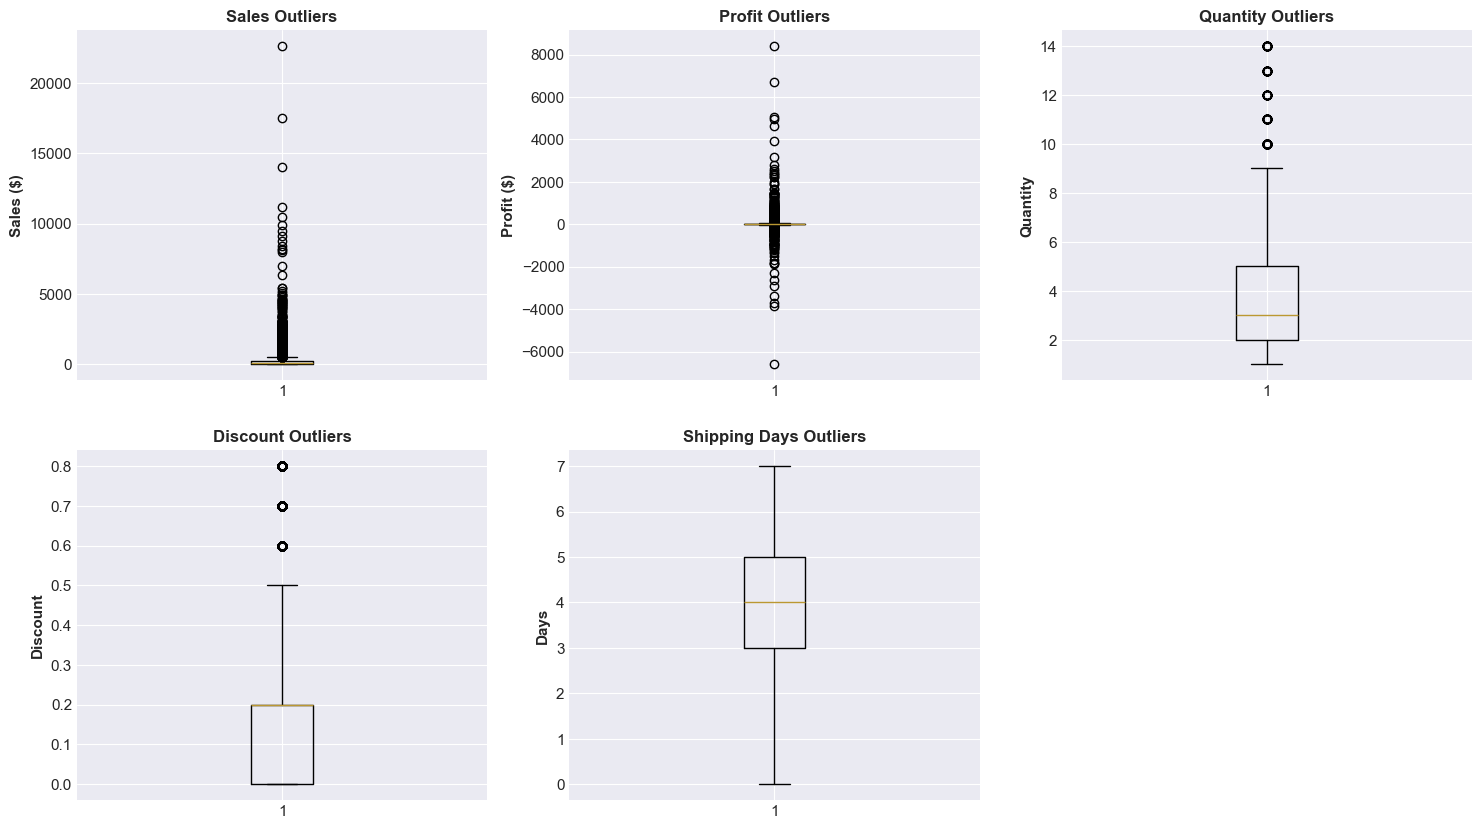

In [45]:
# Box plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sales boxplot
axes[0, 0].boxplot(data['Sales'], vert=True)
axes[0, 0].set_title('Sales Outliers', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Sales ($)')

# Profit boxplot
axes[0, 1].boxplot(data['Profit'], vert=True)
axes[0, 1].set_title('Profit Outliers', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Profit ($)')

# Quantity boxplot
axes[0, 2].boxplot(data['Quantity'], vert=True)
axes[0, 2].set_title('Quantity Outliers', fontweight='bold', fontsize=12)
axes[0, 2].set_ylabel('Quantity')

# Discount boxplot
axes[1, 0].boxplot(data['Discount'], vert=True)
axes[1, 0].set_title('Discount Outliers', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Discount')

# Shipping Days boxplot
axes[1, 1].boxplot(data['Shipping_Days'], vert=True)
axes[1, 1].set_title('Shipping Days Outliers', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Days')

# Remove the empty subplot
fig.delaxes(axes[1, 2])

**Key Insights**

1️⃣ Sales Outliers: Most sales values are low and concentrated near the bottom. There are many extreme outliers, with some orders having very high sales amounts.

2️⃣ Profit Outliers: Profits are grouping near zero. There are both very high positive profits and large negative losses. Negative outliers indicate loss-making transactions. Not all high-sales orders are profitable. Large negative profits may be caused by:Heavy discounts, High shipping costs

3️⃣ Quantity Outliers: orders contain 2–4 items and few orders show very high quantities (10–14 items). Offer volume-based discounts strategically.

4️⃣ Discount Outliers: Most discounts are low or zero. A small orders have very high discounts (60–80%).

5️⃣ Shipping Days Outliers: Most deliveries take 3–5 days. Some orders are delivered very quickly (0–1 days) and other delayed (6–7 days). Delays may be due to: Logistics issues, Location constraints
  - Business actions:
      - Investigate late deliveries to improve customer satisfaction.
      - Use delivery time KPIs for logistics partners.
      - Communicate realistic delivery expectations to customers.

In [46]:
# Calculate outliers using IQR (Interquartile Range) method
numerical_features = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Days'] 
for col in numerical_features:
    Q1 = data[col].quantile(0.25)  # value below which 25% of data lies
    Q3 = data[col].quantile(0.75)  # value below which 75% of data lies
    IQR = Q3 - Q1   # IQR = spread of the middle 50% of data, This shows normal variation.
    lower_bound = Q1 - 1.5 * IQR   # Any value outside this range is considered an outlier.
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]  # Counts records with unusually high or low values.
    print(f"\n📊 {col} Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")


📊 Sales Outliers: 1167 (11.68%)

📊 Quantity Outliers: 170 (1.70%)

📊 Discount Outliers: 856 (8.57%)

📊 Profit Outliers: 1881 (18.82%)

📊 Shipping_Days Outliers: 0 (0.00%)


**Sales Outliers:** Some very big orders, Or pricing variation across products

**Quantity Outliers:** Very stable ordering behavior, customers usually buy similar quantities.

**Discount Outliers:** Could be harming margins

**Profit Outliers:** Many orders have very large profit OR heavy losses due to: High discounts, High-value products

**Shipping_Days Outliers:** Excellent operational consistency. Delivery performance is controlled.

### (8) Profitability Analysis

In [47]:
print(f"\n💰 Profitability Overview:")
print(f"   • Profitable Orders: {len(profitable_orders):,} ({len(profitable_orders)/len(data)*100:.1f}%)")
print(f"   • Unprofitable Orders: {len(unprofitable_orders):,} ({len(unprofitable_orders)/len(data)*100:.1f}%)")
print(f"   • Profitable: ${profitable_orders['Profit'].sum():,.2f}")
print(f"   • Unprofitable: ${unprofitable_orders['Profit'].sum():,.2f}")
print(f"   • Net(Total) Profit: ${data['Profit'].sum():,.2f}")


💰 Profitability Overview:
   • Profitable Orders: 8,058 (80.6%)
   • Unprofitable Orders: 1,936 (19.4%)
   • Profitable: $442,528.31
   • Unprofitable: $-156,131.29
   • Net(Total) Profit: $286,397.02


In [48]:
# Category profitability
print(f"\n📊 Profitability by Category:")
category_profit = data.groupby('Category').agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Order ID': 'count'}).sort_values('Profit', ascending=False)
category_profit['Profit_Margin'] = (category_profit['Profit'] / category_profit['Sales'] * 100)

for category, row in category_profit.iterrows():
    print(f"   • {category:<20} : Profit ${row['Profit']:>12,.2f}, Margin {row['Profit_Margin']:>6.2f}%")

# Product profitability
print(f"\n🏆 Top 10 Most Profitable Products:")
product_profit = data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
for i, (product, profit) in enumerate(product_profit.head(10).items(), 1):
    product_orders = len(data[data['Product Name'] == product])
    print(f"   {i:2d}. {product:<20} → ${profit:>10,.2f} ({product_orders} orders)")

print(f"\n📉 Top 10 Loss-Making Products:")
for i, (product, profit) in enumerate(product_profit.tail(10).items(), 1):
    product_orders = len(data[data['Product Name'] == product])
    print(f"   {i:2d}. {product:<20} → ${profit:>10,.2f} LOSS ({product_orders} orders)")

# Segment profitability
print(f"\n📊 ProfitabilityY by Segment:")
segment_profit = data.groupby('Segment').agg({
    'Profit': ['sum', 'mean'],
    'Sales': 'sum',
    'Order ID': 'count'}).round(2)
segment_profit.columns = ['Total_Profit', 'Avg_Profit', 'Total_Sales', 'Orders']
segment_profit['Profit_Margin'] = (segment_profit['Total_Profit'] / segment_profit['Total_Sales'] * 100)
print(segment_profit)

# Regional profitability
print(f"\n📊 Profitability by Region:")
region_profit = data.groupby('Region').agg({
    'Profit': ['sum', 'mean'],
    'Sales': 'sum',
    'Order ID': 'count'}).round(2)
region_profit.columns = ['Total_Profit', 'Avg_Profit', 'Total_Sales', 'Orders']
region_profit['Profit_Margin'] = (region_profit['Total_Profit'] / region_profit['Total_Sales'] * 100)
print(region_profit)


📊 Profitability by Category:
   • Technology           : Profit $  145,454.95, Margin  17.40%
   • Office Supplies      : Profit $  122,490.80, Margin  17.04%
   • Furniture            : Profit $   18,451.27, Margin   2.49%

🏆 Top 10 Most Profitable Products:
    1. Copiers              → $ 55,617.82 (68 orders)
    2. Phones               → $ 44,515.73 (889 orders)
    3. Accessories          → $ 41,936.64 (775 orders)
    4. Paper                → $ 34,053.57 (1370 orders)
    5. Binders              → $ 30,221.76 (1523 orders)
    6. Chairs               → $ 26,590.17 (617 orders)
    7. Storage              → $ 21,278.83 (846 orders)
    8. Appliances           → $ 18,138.01 (466 orders)
    9. Furnishings          → $ 13,059.14 (957 orders)
   10. Envelopes            → $  6,964.18 (254 orders)

📉 Top 10 Loss-Making Products:
    1. Appliances           → $ 18,138.01 LOSS (466 orders)
    2. Furnishings          → $ 13,059.14 LOSS (957 orders)
    3. Envelopes            → $  6,9

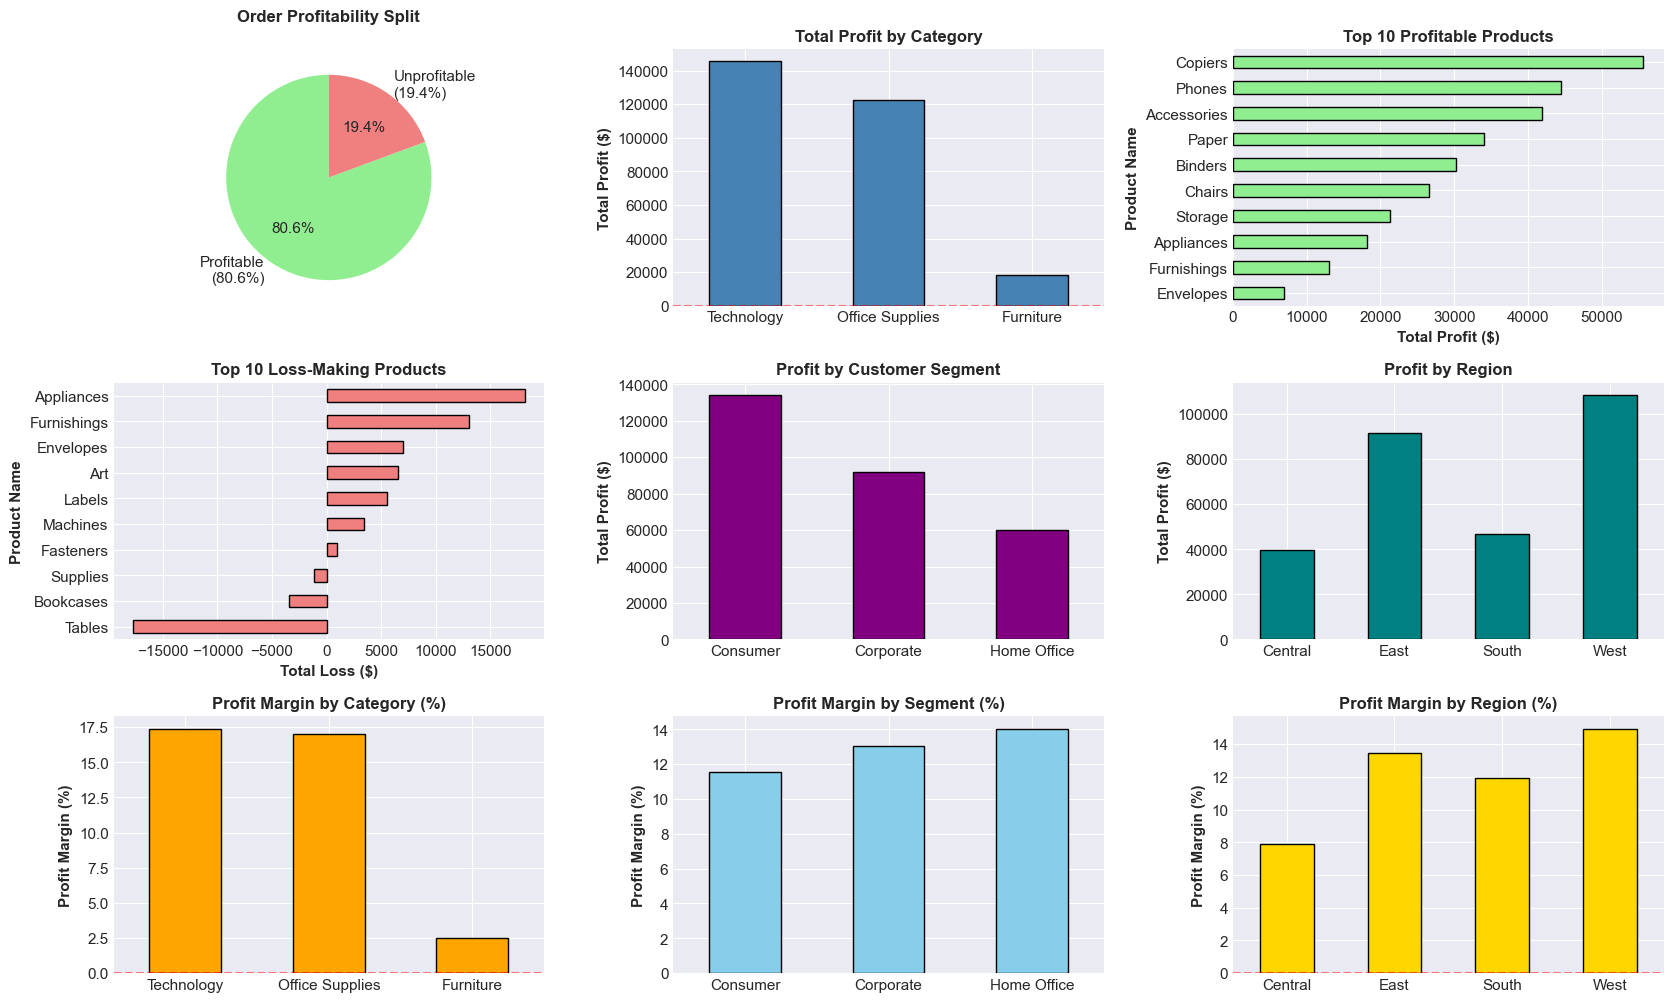

In [49]:
# Visualization: Profitability Analysis
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Profitable vs Unprofitable
ax1 = fig.add_subplot(gs[0, 0])
profit_status = ['Profitable\n(80.6%)', 'Unprofitable\n(19.4%)']
profit_counts = [len(profitable_orders), len(unprofitable_orders)]
colors_pie = ['lightgreen', 'lightcoral']
ax1.pie(profit_counts, labels=profit_status, autopct='%1.1f%%', startangle=90,colors=colors_pie, textprops={'fontsize': 11})
ax1.set_title('Order Profitability Split', fontsize=12, pad=20)

# 2. Profit by category
ax2 = fig.add_subplot(gs[0, 1])
category_profit['Profit'].plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('Total Profit by Category', fontsize=12)
ax2.set_xlabel('', fontsize=11)
ax2.set_ylabel('Total Profit ($)', fontsize=11)
ax2.tick_params(axis='x', rotation=0)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

# 3. Top profitable products
ax3 = fig.add_subplot(gs[0, 2])
product_profit.head(10).plot(kind='barh', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Top 10 Profitable Products', fontsize=12)
ax3.set_xlabel('Total Profit ($)', fontsize=11)
ax3.set_ylabel('Product Name', fontsize=11)
ax3.invert_yaxis()

# 4. Loss-making products
ax4 = fig.add_subplot(gs[1, 0])
product_profit.tail(10).plot(kind='barh', ax=ax4, color='lightcoral', edgecolor='black')
ax4.set_title('Top 10 Loss-Making Products', fontsize=12)
ax4.set_xlabel('Total Loss ($)', fontsize=11)
ax4.set_ylabel('Product Name', fontsize=11)
ax4.invert_yaxis()

# 5. Profit by segment
ax5 = fig.add_subplot(gs[1, 1])
segment_profit['Total_Profit'].plot(kind='bar', ax=ax5, color='purple', edgecolor='black')
ax5.set_title('Profit by Customer Segment', fontsize=12)
ax5.set_xlabel('', fontsize=11)
ax5.set_ylabel('Total Profit ($)', fontsize=11)
ax5.tick_params(axis='x', rotation=0)

# 6. Profit by region
ax6 = fig.add_subplot(gs[1, 2])
region_profit['Total_Profit'].plot(kind='bar', ax=ax6, color='teal', edgecolor='black')
ax6.set_title('Profit by Region', fontsize=12)
ax6.set_xlabel('', fontsize=11)
ax6.set_ylabel('Total Profit ($)', fontsize=11)
ax6.tick_params(axis='x', rotation=0)

# 7. Profit margin by category
ax7 = fig.add_subplot(gs[2, 0])
category_profit['Profit_Margin'].plot(kind='bar', ax=ax7, color='orange', edgecolor='black')
ax7.set_title('Profit Margin by Category (%)', fontsize=12)
ax7.set_xlabel('', fontsize=11)
ax7.set_ylabel('Profit Margin (%)', fontsize=11)
ax7.tick_params(axis='x', rotation=0)
ax7.axhline(0, color='red', linestyle='--', alpha=0.5)

# 8. Profit margin by segment
ax8 = fig.add_subplot(gs[2, 1])
segment_profit['Profit_Margin'].plot(kind='bar', ax=ax8, color='skyblue', edgecolor='black')
ax8.set_title('Profit Margin by Segment (%)', fontsize=12)
ax8.set_xlabel('', fontsize=11)
ax8.set_ylabel('Profit Margin (%)', fontsize=11)
ax8.tick_params(axis='x', rotation=0)

# 9. Profit margin by region
ax9 = fig.add_subplot(gs[2, 2])
region_profit['Profit_Margin'].plot(kind='bar', ax=ax9, color='gold', edgecolor='black')
ax9.set_title('Profit Margin by Region (%)', fontsize=12)
ax9.set_xlabel('', fontsize=11)
ax9.set_ylabel('Profit Margin (%)', fontsize=11)
ax9.tick_params(axis='x', rotation=0)
ax9.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig('profitability_analysis.png', dpi=300, bbox_inches='tight')

**Key Insights**

1️⃣ Profitable vs Unprofitable Orders: Identify patterns in unprofitable orders (discounts, shipping mode, product type). Focus on reducing loss-making orders rather than only increasing sales volume.

2️⃣ Total Profit by Category: Technology products are high-margin and high-impact. Furniture likely suffers from:High shipping costs, Heavy discounts

3️⃣ Top 10 Profitable Product Names: Products like Copiers, Phones, Accessories, and Paper generate the highest profits. Profit is concentrated in a small set of products.

4️⃣ Bottom 10 Product Names by Profit: Products such as Tables, Bookcases, Supplies, and Fasteners generate losses. Losses may be due to: Excessive discounts, High return rates, High transportation

5️⃣ Profit by Customer Segment: Consumer has volume-based profitability. Corporate generate solid profit but fewer orders.

6️⃣ Profit by Region: West is the most profitable and Central has the lowest profit. Differences may be due to Shipping distance.
   - 👉 Action: Replicate West/East strategies in weaker regions. Optimize logistics and pricing in Central and South.
   
7️⃣ Profit Margin by Category: Technology and Office Supplies have high profit margins (~17%). Furniture has a very low margin (~2–3%).

8️⃣ Profit Margin by Segment: Consumer sales rely on high volume, low margin. Home Office customers buy higher-margin items but in smaller volumes.
   - 👉 Action: Increase Home Office sales through targeted offers. Improve Consumer margins via pricing and cost control.
   
9️⃣ Profit Margin by Region: High-profit regions combine strong demand and efficient cost structure. Central region likely suffers from: Higher logistics costs or Lower pricing power
   - 👉 Action: Investigate cost drivers in Central. Apply best practices from West/East regions.   

**Business Insights**

In [50]:
print(f"\n💡 Key Profitability Insights for Business Optimization:")
worst_category = category_profit['Profit'].idxmin()
worst_product = product_profit.idxmin()
worst_segment = segment_profit['Total_Profit'].idxmin()

print(f"\n   ⚠️ Areas Requiring Attention:")
print(f"      • Worst Category: {worst_category} (${category_profit.loc[worst_category, 'Profit']:,.2f})")
print(f"      • Worst Product: {worst_product} (${product_profit[worst_product]:,.2f} loss)")
print(f"      • Lowest Segment: {worst_segment}")

unprofitable_by_discount = unprofitable_orders['Discount'].mean()
profitable_by_discount = profitable_orders['Discount'].mean()

print(f"\n   📉 Loss Drivers:")
print(f"      • Avg discount in unprofitable orders: {unprofitable_by_discount:.1%}")
print(f"      • Avg discount in profitable orders: {profitable_by_discount:.1%}")
print(f"      • Excess discounting causes {unprofitable_by_discount - profitable_by_discount:.1%} more losses")


💡 Key Profitability Insights for Business Optimization:

   ⚠️ Areas Requiring Attention:
      • Worst Category: Furniture ($18,451.27)
      • Worst Product: Tables ($-17,725.48 loss)
      • Lowest Segment: Home Office

   📉 Loss Drivers:
      • Avg discount in unprofitable orders: 46.9%
      • Avg discount in profitable orders: 8.1%
      • Excess discounting causes 38.8% more losses


### (9) Segment wise  Analysis (Consumer, Corporate, Home Office)

In [51]:
# Analysis by segment (Consumer, Corporate, Home Office)
segment_analysis = data.groupby('Segment').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Discount': 'mean',
    'Quantity': 'sum'}).round(2)

print(f"\n📊 Segment-wise Performance:")
segment_analysis


📊 Segment-wise Performance:


Sales                   Profit        Discount Quantity
                    sum    mean count        sum   mean     mean      sum
Segment                                                                  
Consumer     1161401.34  223.73  5191  134119.21  25.84     0.16    19521
Corporate     706146.37  233.82  3020   91979.13  30.46     0.16    11608
Home Office   429653.15  240.97  1783   60298.68  33.82     0.15     6744

In [52]:
# Category preference by segment
print(f"\n📊 Top Category by Segment:")
for segment in data['Segment'].unique():
    top_category = data[data['Segment'] == segment]['Category'].value_counts().head(1)
    print(f"   {segment}: {top_category.index[0]} ({top_category.values[0]} orders)")


📊 Top Category by Segment:
   Consumer: Office Supplies (3127 orders)
   Corporate: Office Supplies (1820 orders)
   Home Office: Office Supplies (1079 orders)


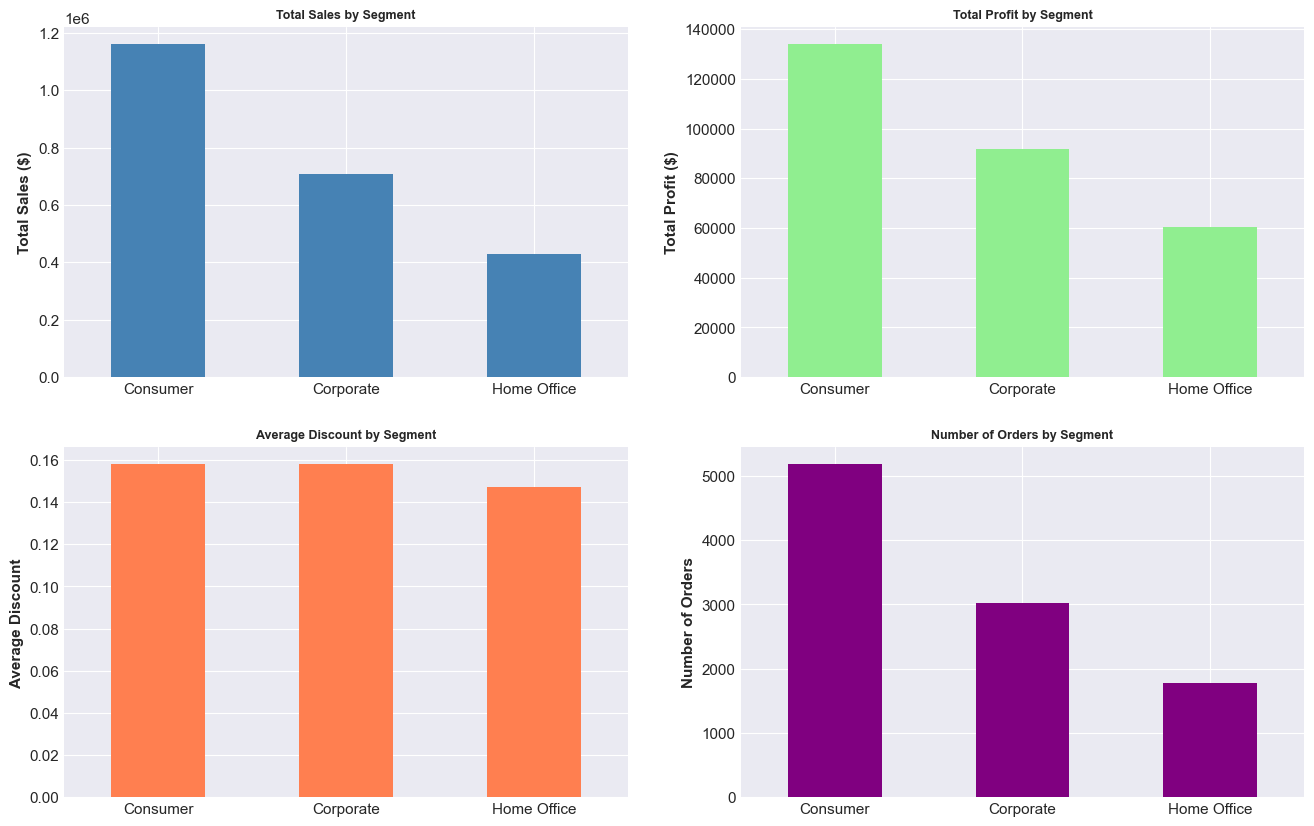

In [53]:
# Visualize segment analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales by segment
data.groupby('Segment')['Sales'].sum().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Total Sales by Segment', fontweight='bold', fontsize=9)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=0)

# Profit by segment
data.groupby('Segment')['Profit'].sum().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Total Profit by Segment', fontweight='bold', fontsize=9)
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Total Profit ($)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Average discount by segment
data.groupby('Segment')['Discount'].mean().plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Average Discount by Segment', fontweight='bold', fontsize=9)
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Average Discount')
axes[1, 0].tick_params(axis='x', rotation=0)

# Orders by segment
data['Segment'].value_counts().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Number of Orders by Segment', fontweight='bold', fontsize=9)
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Number of Orders')
axes[1, 1].tick_params(axis='x', rotation=0)

**Key Insights**

1️⃣ Total Sales by Segment: The Consumer segment is the main revenue driver. Protect and grow Consumer sales while creating strategies to increase Home Office revenue.

2️⃣ Total Profit by Segment: Consumer also generates the highest profit. Home Office produces the lowest profit.

3️⃣ Average Discount by Segment: Consumer and Corporate have almost the same average discount. Despite similar discounts, Consumer performs much better → strong demand. Home Office gets lower discounts but also lower sales, which may mean: Discounts are not the main issue
   - 📌 Action: Test targeted discounts or promotions for Home Office instead of general discounts.

4️⃣ Number of Orders by Segment: Consumer has the highest number of orders. Home Office has the fewest orders.

### (10) Region Performance Comparsion (Central, East, South, West)

In [54]:
# Regional analysis (Central, East, South, West)
regional_analysis = data.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Discount': 'mean',
    'Customer ID': 'nunique'}).round(2)
regional_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Profit', 'Avg_Discount', 'Unique_Customers']

print(f"\n📊 Regional Performance Summary:")
regional_analysis


📊 Regional Performance Summary:


,Total_Sales,Avg_Sales,Total_Profit,Avg_Profit,Avg_Discount,Unique_Customers
Region,,,,,,
Central,501239.89,215.77,39706.36,17.09,0.24,629
East,678781.24,238.34,91522.78,32.14,0.15,674
South,391721.90,241.80,46749.43,28.86,0.15,512
West,725457.82,226.49,108418.45,33.85,0.11,686


In [55]:
# Best and worst performing regions
print(f"\n🏆 Best Region by Profit: {regional_analysis['Total_Profit'].idxmax()}")
print(f"   Profit: ${regional_analysis['Total_Profit'].max():,.2f}")
print(f"\n📉 Worst Region by Profit: {regional_analysis['Total_Profit'].idxmin()}")
print(f"   Profit: ${regional_analysis['Total_Profit'].min():,.2f}")


🏆 Best Region by Profit: West
   Profit: $108,418.45

📉 Worst Region by Profit: Central
   Profit: $39,706.36


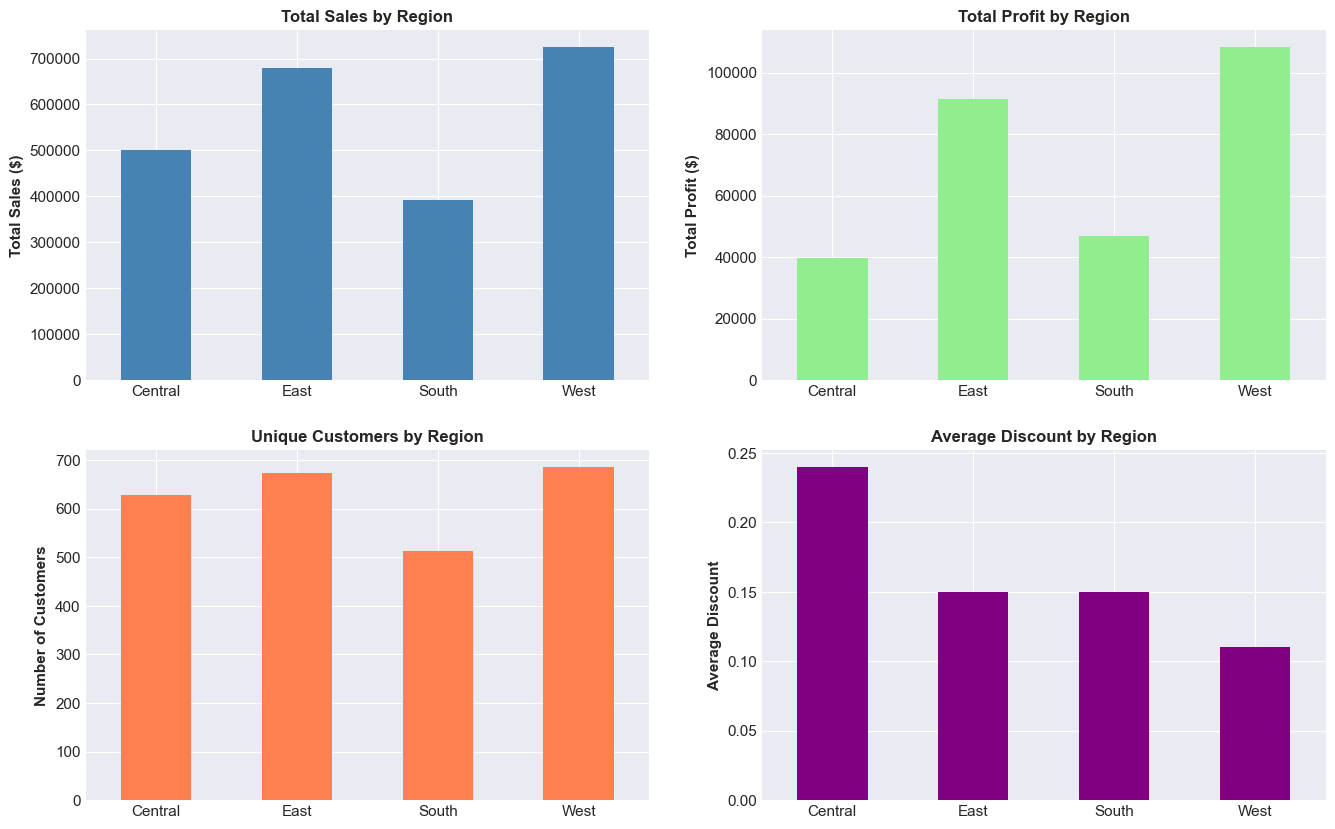

In [56]:
# Visualize regional comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales by region
regional_analysis['Total_Sales'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Total Sales by Region', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=0)

# Profit by region
regional_analysis['Total_Profit'].plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Total Profit by Region', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Total Profit ($)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Customers by region
regional_analysis['Unique_Customers'].plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Unique Customers by Region', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].tick_params(axis='x', rotation=0)

# Average discount by region
regional_analysis['Avg_Discount'].plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Discount by Region', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Average Discount')
axes[1, 1].tick_params(axis='x', rotation=0)

**Key Insights**

1️⃣ Total Sales by Region:West has the highest total sales. South has the lowest sales.
   - 📌 Action: Focus growth in South while continuing to strengthen West and East dominance.

2️⃣ Total Profit by Region: West combines high sales with strong profitability → best-performing region. Central’s profit is relatively low compared to its sales, indicating Higher operating costs, Heavy discounting. South profitability is weak due to low sales volume.

3️⃣ Unique Customers by Region: High sales in West and East are supported by large customer bases. South’s low customer count explains its poor sales performance. Central has reasonable customers but underperforms in profit.

4️⃣ Average Discount by Region: Despite lower discounts, West achieves the highest sales and profit → strong market position. Central gives high discounts but does not get high profit, hurting margins. Discounting in South does not significantly increase sales.
  - Action: 
      - Reduce unnecessary discounts in Central
      - Maintain premium pricing strategy in West.
      - Reevaluate discount effectiveness in South.

### (11) Category × Segment Interaction

In [57]:
# Cross-tabulation
category_segment = pd.crosstab(data['Category'], data['Segment'], values=data['Sales'], aggfunc='sum')

print(f"\n📊 Sales by Category and Segment:")
category_segment


📊 Sales by Category and Segment:


Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,391049.312,229019.7858,121930.6975
Office Supplies,363952.136,230676.4620,124418.4340
Technology,406399.897,246450.1190,183304.0170


(array([0, 1, 2]),
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Office Supplies'),
  Text(2, 0, 'Technology')])

<Figure size 400x200 with 0 Axes>

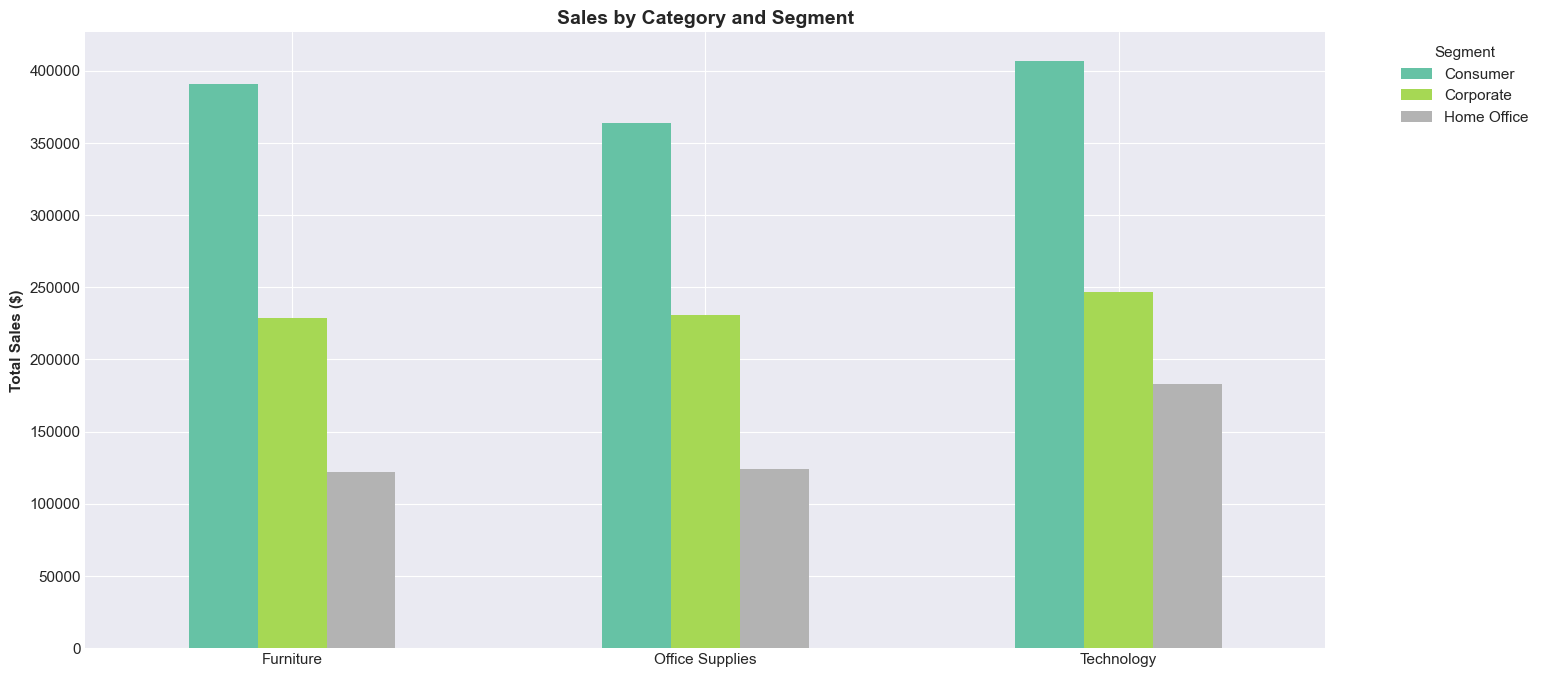

In [58]:
# Visualize category-segment interaction
plt.figure(figsize=(4, 2))
category_segment.plot(kind='bar', stacked=False, colormap='Set2')
plt.title('Sales by Category and Segment', fontsize=14, fontweight='bold')
plt.xlabel('', fontweight='bold')
plt.ylabel('Total Sales ($)', fontweight='bold')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

### (12) Time Series Trends

In [59]:
# Monthly trends
monthly_data = data.groupby(data['Order Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'}).reset_index()

monthly_data['Order Date'] = monthly_data['Order Date'].dt.to_timestamp()
monthly_data.columns = ['Date', 'Sales', 'Profit', 'Orders']

print(f"\n📊 Monthly Trends (Last 12 Months):")
monthly_data.tail(12)


📊 Monthly Trends (Last 12 Months):


,Date,Sales,Profit,Orders
36,2017-01-01,43971.3740,7140.4391,155
37,2017-02-01,20301.1334,1613.8720,107
38,2017-03-01,58872.3528,14751.8915,238
39,2017-04-01,36521.5361,933.2900,203
40,2017-05-01,44261.1102,6342.5828,242
41,2017-06-01,52981.7257,8223.3357,245
42,2017-07-01,45264.4160,6952.6212,226
43,2017-08-01,63120.8880,9040.9557,218
44,2017-09-01,87866.6520,10991.5556,459
45,2017-10-01,77776.9232,9275.2755,298


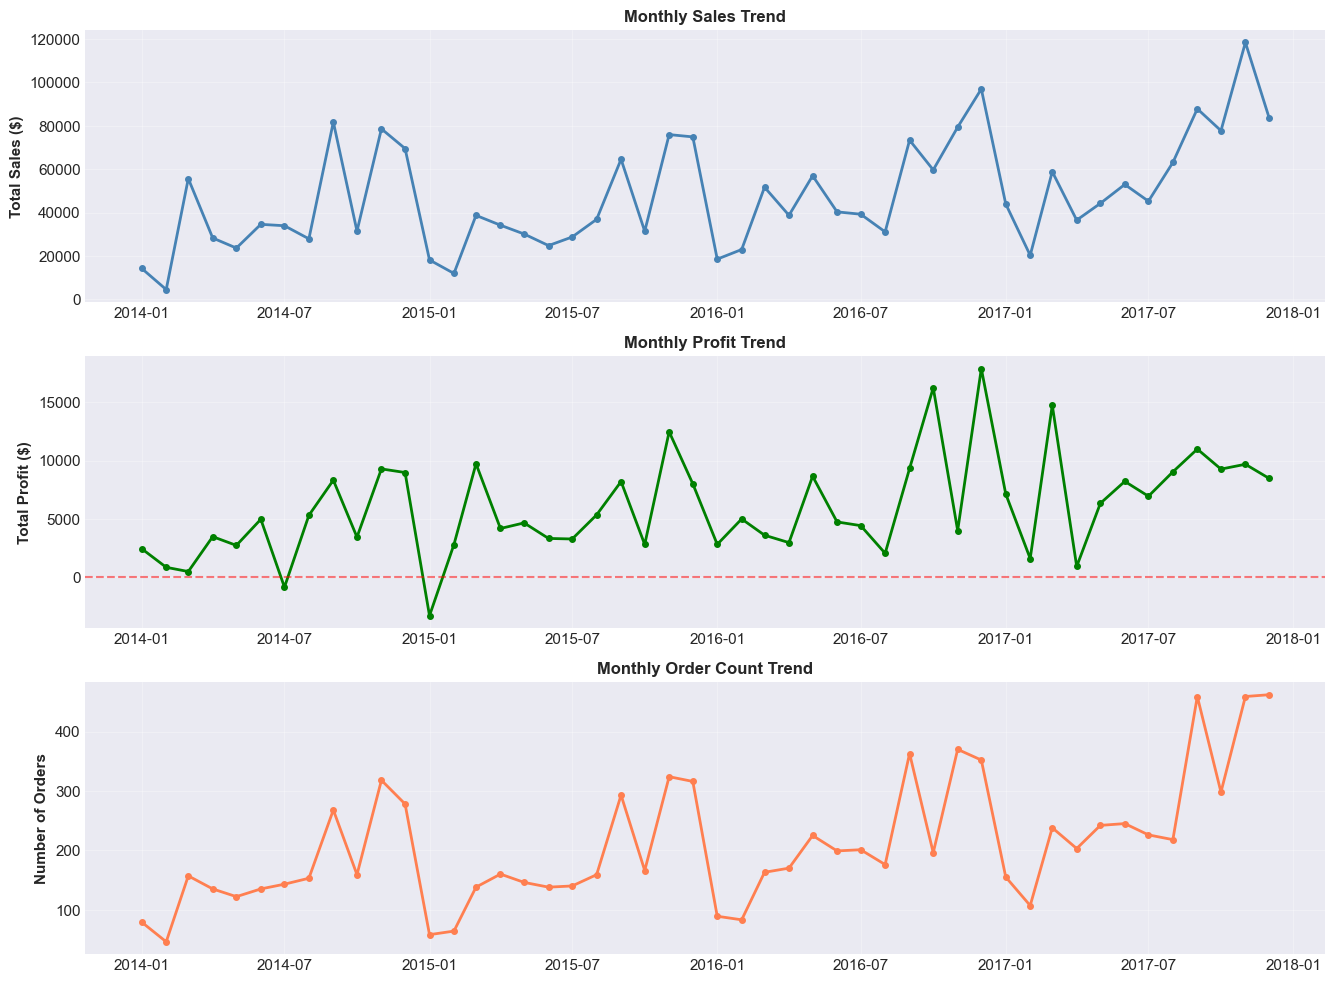

In [60]:
# Visualize time series
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Sales over time
axes[0].plot(monthly_data['Date'], monthly_data['Sales'], marker='o', linewidth=2, color='steelblue', markersize=4)
axes[0].set_title('Monthly Sales Trend', fontweight='bold', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Sales ($)')
axes[0].grid(alpha=0.3)

# Profit over time
axes[1].plot(monthly_data['Date'], monthly_data['Profit'], marker='o', linewidth=2, color='green', markersize=4)
axes[1].set_title('Monthly Profit Trend', fontweight='bold', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Profit ($)')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

# Orders over time
axes[2].plot(monthly_data['Date'], monthly_data['Orders'], marker='o', linewidth=2, color='coral', markersize=4)
axes[2].set_title('Monthly Order Count Trend', fontweight='bold', fontsize=12)
axes[2].set_xlabel('')
axes[2].set_ylabel('Number of Orders')
axes[2].grid(alpha=0.3)

**Key Insights**

1️⃣ Monthly Sales Trend: overall upward trend from 2014 to 2017. Notice seasonal peaks, especially end of each year. Lowest sales appear at the beginning of years.

2️⃣ Monthly Profit Trend: Some months show very low or negative profit (below the red zero line). Profit peaks become higher in later years, especially in 2016–2017.

3️⃣ Monthly Order Count Trend: Order volume increases over time. Significant growth in orders in 2017. Some months show many orders but weaker profit → low-margin sales.

### Key Insigts Summary

In [61]:
insights = f"""

1. Customer Insights
   - Consumer segment dominates with {(data['Segment'].value_counts()['Consumer']/len(data)*100):.1f}% of orders
   - Top customer has {data['Customer ID'].value_counts().iloc[0]} orders
   - Average orders per customer: {(len(data)/data['Customer ID'].nunique()):.2f}

2. Geographical Patterns
   - {data['Region'].value_counts().index[0]} region leads in orders
   - {data['State'].value_counts().index[0]} is the top state
   - Regional performance varies significantly in profitability

3. Product Analysis
   - {data['Category'].value_counts().index[0]} category has most orders
   - {data.groupby('Product Name')['Profit'].sum().idxmax()} is most profitable Product Name
   - {data.groupby('Product Name')['Profit'].sum().idxmin()} has highest losses
   
4. Financial Performance
   - Profitable orders: {(len(profitable_orders)/len(data)*100):.1f}%
   - Average profit margin: {data['Profit_Margin'].mean():.2f}%
   - Strong correlation between Sales and Profit: {data[['Sales', 'Profit']].corr().iloc[0,1]:.3f}

5. Discount Impact
   - Average discount: {data['Discount'].mean():.2%}
   - Orders with discount: {(data['Discount'] > 0).sum()/len(data)*100:.1f}%
   - Discount shows negative correlation with profit

6. Shipping Patterns
   - {data['Ship Mode'].value_counts().index[0]} is most common shipping mode
   - Average shipping time: {data['Shipping_Days'].mean():.1f} days
   - Shipping mode affects sales distribution

7. Temporal Trends
   - Peak sales month: {data.groupby('Month_Name')['Sales'].sum().idxmax()}
   - Busiest day: {data['Day_Name'].value_counts().index[0]}
   - Clear seasonal patterns observed

8. Data Quality
   - Missing values: {data.isnull().sum().sum()} (very clean dataset)
   - Outliers detected in Sales, Profit, and Quantity
   - Data is ready for modeling with minimal preprocessing
   
9. Business Recommendations
    - Focus on {data.groupby('Segment')['Profit'].sum().idxmax()} segment for profitability
    - Optimize discount strategy in loss-making Product Name
    - Investigate {data.groupby('Product Name')['Profit'].sum().idxmin()} for losses
    - Leverage seasonal trends for inventory planning
    - Target {data.groupby('Region')['Profit'].sum().idxmax()} region expansion
"""
print(insights)   



1. Customer Insights
   - Consumer segment dominates with 51.9% of orders
   - Top customer has 37 orders
   - Average orders per customer: 12.60

2. Geographical Patterns
   - West region leads in orders
   - California is the top state
   - Regional performance varies significantly in profitability

3. Product Analysis
   - Office Supplies category has most orders
   - Copiers is most profitable Product Name
   - Tables has highest losses

4. Financial Performance
   - Profitable orders: 80.6%
   - Average profit margin: 12.03%
   - Strong correlation between Sales and Profit: 0.479

5. Discount Impact
   - Average discount: 15.62%
   - Orders with discount: 52.0%
   - Discount shows negative correlation with profit

6. Shipping Patterns
   - Standard Class is most common shipping mode
   - Average shipping time: 4.0 days
   - Shipping mode affects sales distribution

7. Temporal Trends
   - Peak sales month: November
   - Busiest day: Monday
   - Clear seasonal patterns observed



In [62]:
# Save in the same directory as current notebook
data.to_csv(os.path.join(os.getcwd(), "Customer_Segmentation&Sales_Forecasting_Dataset.csv"), index=False)